# Reporting Layer — Notebooks 8 → 9: Model Comparison & Final Recommendation Demo

Notebook này là **lớp báo cáo bổ sung** cho nhóm cuối của đồ án:

- **8_Compare_ALS_vs_NCF**: tổng hợp metric và vai trò của Spark ALS với Hybrid TensorFlow NCF.
- **9_Final_Recommendation_Demo**: demo gợi ý phim cuối cùng theo luồng ALS candidate generation → NCF reranking.

Mục tiêu:

- Không sửa notebook cũ.
- Không train lại ALS/NCF.
- Không chạy lại recommendation demo nếu output đã có.
- Đọc lại toàn bộ output đã sinh trong `/workspace/outputs/metrics`, `/workspace/outputs/recommendations`, `/workspace/outputs/figures`.
- Tạo thêm bảng, biểu đồ, sơ đồ và markdown để đưa vào báo cáo/slide.

Output reporting mới được ghi vào:

```text
/workspace/outputs/reporting/reporting_layer_8_9_final_comparison_demo/
```

In [1]:
import os
import json
import glob
import math
import textwrap
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    SEABORN_AVAILABLE = False

from IPython.display import display, HTML, Markdown, Image

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

PROJECT_ROOT = Path("/workspace")
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
RECOMMENDATIONS_DIR = OUTPUTS_DIR / "recommendations"
SOURCE_FIGURES_DIR = OUTPUTS_DIR / "figures"
NCF_DIR = OUTPUTS_DIR / "ncf"
MODELS_DIR = PROJECT_ROOT / "models"

REPORT_SLUG = "reporting_layer_8_9_final_comparison_demo"
REPORT_DIR = OUTPUTS_DIR / "reporting" / REPORT_SLUG
FIG_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
METRIC_DIR = REPORT_DIR / "metrics"
MARKDOWN_DIR = REPORT_DIR / "markdown"

for d in [FIG_DIR, TABLE_DIR, METRIC_DIR, MARKDOWN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

figure_exports = {}
table_exports = {}
metric_exports = {}

RUN_TIMESTAMP = datetime.now().isoformat(timespec="seconds")

CUSTOM_CSS = """
<style>
    .rendered_html table, .dataframe {
        direction: ltr !important;
        text-align: left !important;
        margin-left: 0 !important;
        margin-right: auto !important;
    }
    .rendered_html th, .rendered_html td,
    table.dataframe th, table.dataframe td {
        text-align: left !important;
        vertical-align: top !important;
        white-space: normal !important;
        word-break: normal !important;
        overflow-wrap: break-word !important;
    }
</style>
"""
display(HTML(CUSTOM_CSS))

print("Report directory:", REPORT_DIR)
print("Seaborn available:", SEABORN_AVAILABLE)

Report directory: /workspace/outputs/reporting/reporting_layer_8_9_final_comparison_demo
Seaborn available: True


In [2]:
def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)
    metric_exports[path.stem] = str(path)
    return path


def read_json_if_exists(path, default=None):
    path = Path(path)
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    return default


def read_csv_if_exists(path, default=None):
    path = Path(path)
    if path.exists():
        try:
            return pd.read_csv(path)
        except Exception as exc:
            print(f"Cannot read CSV {path}: {exc}")
    return pd.DataFrame() if default is None else default


def latest_file(pattern):
    matches = glob.glob(str(pattern))
    if not matches:
        return None
    return max(matches, key=lambda p: os.path.getmtime(p))


def safe_get(d, key, default=None):
    return d.get(key, default) if isinstance(d, dict) else default


def human_int(x):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        return f"{int(round(float(x))):,}"
    except Exception:
        return str(x)


def human_float(x, digits=4):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)


def human_pct(x, digits=2):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        return f"{float(x) * 100:.{digits}f}%"
    except Exception:
        return str(x)


def compact_number(x):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        x = float(x)
    except Exception:
        return str(x)
    sign = "-" if x < 0 else ""
    x = abs(x)
    if x >= 1_000_000_000:
        return f"{sign}{x/1_000_000_000:.2f}B"
    if x >= 1_000_000:
        return f"{sign}{x/1_000_000:.2f}M"
    if x >= 1_000:
        return f"{sign}{x/1_000:.2f}K"
    if x == int(x):
        return f"{sign}{int(x)}"
    return f"{sign}{x:.3f}"


def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    table_exports[name] = str(path)
    return path


def display_df(df, title=None, max_rows=30):
    if title:
        display(Markdown(f"### {title}"))
    if df is None or len(df) == 0:
        display(Markdown("_Không có dữ liệu để hiển thị._"))
        return
    styled = (
        df.head(max_rows)
        .style
        .set_properties(**{
            "text-align": "left",
            "white-space": "pre-wrap",
            "vertical-align": "top",
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("text-align", "left"),
                ("vertical-align", "top"),
                ("white-space", "pre-wrap"),
            ]},
            {"selector": "td", "props": [
                ("text-align", "left"),
                ("vertical-align", "top"),
                ("white-space", "pre-wrap"),
            ]},
        ])
    )
    display(styled)


def wrap_cell_text(value, width=30):
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass

    text = str(value)
    if not text:
        return ""

    wrapped_parts = []
    for line in text.splitlines():
        if len(line) <= width:
            wrapped_parts.append(line)
        else:
            wrapped_parts.extend(
                textwrap.wrap(
                    line,
                    width=width,
                    break_long_words=False,
                    break_on_hyphens=False,
                )
            )
    return "\n".join(wrapped_parts)


def save_table_image(
    df,
    name,
    title=None,
    max_rows=18,
    wrap_width=30,
    font_size=8,
    scale_y=1.2,
    wrap_widths=None,
    col_widths=None,
    fig_width=None,
):
    """
    Save dataframe as a left-aligned, wrapped PNG table.
    Designed to avoid cropped / overflowed text in report and slide assets.
    """
    if df is None or len(df) == 0:
        return None

    data = df.head(max_rows).copy()
    n_rows, n_cols = data.shape

    wrap_widths = wrap_widths or {}
    default_effective_wrap_width = max(18, min(wrap_width, int(110 / max(n_cols, 1))))

    for col in data.columns:
        effective_width = wrap_widths.get(col, default_effective_wrap_width)
        data[col] = data[col].map(lambda x: wrap_cell_text(x, width=effective_width))

    row_line_counts = []
    for _, row in data.iterrows():
        max_lines = 1
        for value in row.values:
            max_lines = max(max_lines, str(value).count("\n") + 1)
        row_line_counts.append(max_lines)

    if fig_width is None:
        fig_w = max(12, min(30, n_cols * 3.5))
    else:
        fig_w = fig_width

    header_h = 0.65
    title_h = 0.72 if title else 0.25
    body_h = sum(max(0.45, 0.25 * lines) for lines in row_line_counts)
    fig_h = max(3.2, title_h + header_h + body_h) * scale_y

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", pad=14, loc="left")

    table_bbox = [0, 0, 1, 0.92 if title else 1]

    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="left",
        colLoc="left",
        loc="upper left",
        bbox=table_bbox,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)

    if col_widths is None:
        col_widths = [1.0 / max(n_cols, 1)] * n_cols
    else:
        total_width = sum(col_widths)
        col_widths = [w / total_width for w in col_widths]

    header_units = 1.4
    row_units = [max(1.0, 0.7 + 0.45 * lines) for lines in row_line_counts]
    total_units = header_units + sum(row_units)
    available_h = table_bbox[3]

    header_cell_h = available_h * header_units / total_units
    body_cell_heights = [available_h * u / total_units for u in row_units]

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("#D0D7DE")
        cell.set_linewidth(0.5)
        cell.PAD = 0.035
        cell.get_text().set_ha("left")
        cell.get_text().set_va("center")
        cell.get_text().set_wrap(True)
        if col_idx < len(col_widths):
            cell.set_width(col_widths[col_idx])
        if row_idx == 0:
            cell.set_facecolor("#F3F4F6")
            cell.set_text_props(weight="bold", ha="left", va="center", fontsize=font_size + 1)
            cell.set_height(header_cell_h)
        else:
            cell.set_text_props(ha="left", va="center", fontsize=font_size)
            cell.set_height(body_cell_heights[row_idx - 1])

    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    figure_exports[name] = str(path)
    plt.show()
    plt.close(fig)
    return path


def save_figure(name):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=220, bbox_inches="tight")
    figure_exports[name] = str(path)
    plt.show()
    plt.close()
    return path


def save_markdown(text, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return path


def preview_figures(keys=None, max_width=900):
    if keys is None:
        keys = list(figure_exports.keys())
    display(Markdown("### Preview: generated figures"))
    shown = 0
    for key in keys:
        path = figure_exports.get(key)
        if path and Path(path).exists():
            display(Markdown(f"**{key}**"))
            display(Image(filename=path, width=max_width))
            shown += 1
    if shown == 0:
        display(Markdown("_Chưa có figure nào để preview._"))


def get_metric(data, *keys):
    if not isinstance(data, dict):
        return None
    for key in keys:
        if key in data:
            return data[key]
    return None

## 1. Load output thật từ notebook 8 và 9

Cell dưới đây chỉ đọc lại file đã được sinh ra trước đó. Nếu một số file chưa tồn tại, notebook sẽ hiển thị trạng thái thiếu file và bỏ qua phần biểu đồ phụ thuộc vào file đó, thay vì tự điền metric cứng.

In [3]:
als_metrics = read_json_if_exists(METRICS_DIR / "als_metrics.json", default={}) or {}
ncf_metrics = read_json_if_exists(METRICS_DIR / "ncf_metrics.json", default={}) or {}
model_comparison_json = read_json_if_exists(METRICS_DIR / "model_comparison.json", default=None)
model_comparison_csv = METRICS_DIR / "model_comparison.csv"

if model_comparison_csv.exists():
    model_comparison_df = pd.read_csv(model_comparison_csv)
elif isinstance(model_comparison_json, list):
    model_comparison_df = pd.DataFrame(model_comparison_json)
else:
    model_comparison_df = pd.DataFrame([
        {
            "model": "Spark ALS",
            "task": "Rating prediction / Candidate recommendation",
            "main_metric": "RMSE/MAE",
            "rmse": get_metric(als_metrics, "rmse"),
            "mae": get_metric(als_metrics, "mae"),
            "loss": None,
            "accuracy": None,
            "auc": None,
            "uses_genome_features": False,
            "input_features": "userId, movieId, rating",
        },
        {
            "model": "Hybrid TensorFlow NCF",
            "task": "Binary preference prediction / Re-ranking",
            "main_metric": "Loss/Accuracy/AUC",
            "rmse": None,
            "mae": None,
            "loss": get_metric(ncf_metrics, "loss"),
            "accuracy": get_metric(ncf_metrics, "accuracy", "binary_accuracy"),
            "auc": get_metric(ncf_metrics, "auc"),
            "uses_genome_features": get_metric(ncf_metrics, "uses_genome_features"),
            "input_features": "user_idx, movie_idx, movie_genome_features[movie_idx]",
        },
    ])

final_dataset_summary_df = read_csv_if_exists(RECOMMENDATIONS_DIR / "final_dataset_summary.csv")
model_roles_df = read_csv_if_exists(RECOMMENDATIONS_DIR / "final_model_roles.csv")
final_als_metrics_df = read_csv_if_exists(RECOMMENDATIONS_DIR / "final_als_metrics.csv")
final_ncf_metrics_df = read_csv_if_exists(RECOMMENDATIONS_DIR / "final_ncf_metrics.csv")
comparison_summary_df = read_csv_if_exists(RECOMMENDATIONS_DIR / "final_model_comparison_summary.csv")
final_output_files_df = read_csv_if_exists(RECOMMENDATIONS_DIR / "final_output_files.csv")
demo_summary = read_json_if_exists(RECOMMENDATIONS_DIR / "final_demo_summary.json", default={}) or {}

# Load demo recommendation CSVs. Prefer paths recorded in final_demo_summary.json if present.
liked_path = latest_file(RECOMMENDATIONS_DIR / "user_*_liked_movies.csv")
als_path = demo_summary.get("als_recommendation_output_file") or latest_file(RECOMMENDATIONS_DIR / "user_*_als_top_10.csv")
hybrid_path = demo_summary.get("hybrid_recommendation_output_file") or latest_file(RECOMMENDATIONS_DIR / "user_*_hybrid_als_ncf_top_10.csv")

liked_movies_df = read_csv_if_exists(liked_path) if liked_path else pd.DataFrame()
als_recommendations_df = read_csv_if_exists(als_path) if als_path else pd.DataFrame()
hybrid_recommendations_df = read_csv_if_exists(hybrid_path) if hybrid_path else pd.DataFrame()

# If final output inventory was not generated, build it from known output folders.
if len(final_output_files_df) == 0:
    inventory_rows = []
    for pattern in [
        RECOMMENDATIONS_DIR / "*.csv",
        RECOMMENDATIONS_DIR / "*.json",
        METRICS_DIR / "*.json",
        METRICS_DIR / "*.csv",
        SOURCE_FIGURES_DIR / "*.png",
        NCF_DIR / "*.npy",
        NCF_DIR / "*.csv",
        MODELS_DIR / "**/*",
    ]:
        for p in glob.glob(str(pattern), recursive=True):
            p = Path(p)
            if p.is_file():
                inventory_rows.append({
                    "file": str(p),
                    "size_kb": round(p.stat().st_size / 1024, 2),
                })
    final_output_files_df = pd.DataFrame(inventory_rows).sort_values("file") if inventory_rows else pd.DataFrame(columns=["file", "size_kb"])

asset_inventory_rows = [
    {"asset": "als_metrics.json", "path": str(METRICS_DIR / "als_metrics.json"), "loaded": bool(als_metrics)},
    {"asset": "ncf_metrics.json", "path": str(METRICS_DIR / "ncf_metrics.json"), "loaded": bool(ncf_metrics)},
    {"asset": "model_comparison.csv/json", "path": str(METRICS_DIR), "loaded": len(model_comparison_df) > 0},
    {"asset": "final_dataset_summary.csv", "path": str(RECOMMENDATIONS_DIR / "final_dataset_summary.csv"), "loaded": len(final_dataset_summary_df) > 0},
    {"asset": "final_model_roles.csv", "path": str(RECOMMENDATIONS_DIR / "final_model_roles.csv"), "loaded": len(model_roles_df) > 0},
    {"asset": "final_demo_summary.json", "path": str(RECOMMENDATIONS_DIR / "final_demo_summary.json"), "loaded": bool(demo_summary)},
    {"asset": "liked_movies.csv", "path": str(liked_path), "loaded": len(liked_movies_df) > 0},
    {"asset": "als_top_10.csv", "path": str(als_path), "loaded": len(als_recommendations_df) > 0},
    {"asset": "hybrid_top_10.csv", "path": str(hybrid_path), "loaded": len(hybrid_recommendations_df) > 0},
    {"asset": "final_output_files.csv", "path": str(RECOMMENDATIONS_DIR / "final_output_files.csv"), "loaded": len(final_output_files_df) > 0},
]
asset_inventory_df = pd.DataFrame(asset_inventory_rows)

save_table(asset_inventory_df, "final_reporting_asset_inventory")
display_df(asset_inventory_df, "Loaded assets for notebooks 8 → 9", max_rows=30)

save_json({
    "run_timestamp": RUN_TIMESTAMP,
    "report_slug": REPORT_SLUG,
    "loaded_assets": asset_inventory_rows,
}, METRIC_DIR / "final_reporting_asset_inventory.json")

### Loaded assets for notebooks 8 → 9

,asset,path,loaded
0,als_metrics.json,/workspace/outputs/metrics/als_metrics.json,True
1,ncf_metrics.json,/workspace/outputs/metrics/ncf_metrics.json,True
2,model_comparison.csv/json,/workspace/outputs/metrics,True
3,final_dataset_summary.csv,/workspace/outputs/recommendations/final_dataset_summary.csv,True
4,final_model_roles.csv,/workspace/outputs/recommendations/final_model_roles.csv,True
5,final_demo_summary.json,/workspace/outputs/recommendations/final_demo_summary.json,True
6,liked_movies.csv,/workspace/outputs/recommendations/user_3_liked_movies.csv,True
7,als_top_10.csv,/workspace/outputs/recommendations/user_3_als_top_10.csv,True
8,hybrid_top_10.csv,/workspace/outputs/recommendations/user_3_hybrid_als_ncf_top_10.csv,True
9,final_output_files.csv,/workspace/outputs/recommendations/final_output_files.csv,True


PosixPath('/workspace/outputs/reporting/reporting_layer_8_9_final_comparison_demo/metrics/final_reporting_asset_inventory.json')

## 2. So sánh vai trò ALS và Hybrid NCF

Notebook 8 đã tạo `model_comparison.csv/json`. Reporting layer này đọc lại bảng đó rồi bổ sung bảng diễn giải để tránh hiểu nhầm: **ALS dùng RMSE/MAE cho bài toán rating prediction**, còn **Hybrid NCF dùng Loss/Accuracy/AUC cho bài toán binary preference / reranking**. Hai nhóm metric không nên so sánh trực tiếp như cùng một thang đo.

### Model comparison from notebook 8

,model,task,main_metric,rmse,mae,loss,accuracy,auc,uses_genome_features,input_features,rmse_display,mae_display,loss_display,accuracy_display,auc_display
0,Spark ALS,Rating prediction / Candidate recommendation,RMSE/MAE,0.778017,0.604163,nan,nan,nan,False,"userId, movieId, rating",0.7780,0.6042,N/A,N/A,N/A
1,Hybrid TensorFlow NCF,Binary preference prediction / Re-ranking,Loss/Accuracy/AUC,nan,nan,0.198242,0.930179,0.974705,True,"user_idx, movie_idx, movie_genome_features[movie_idx]",N/A,N/A,0.1982,0.9302,0.9747


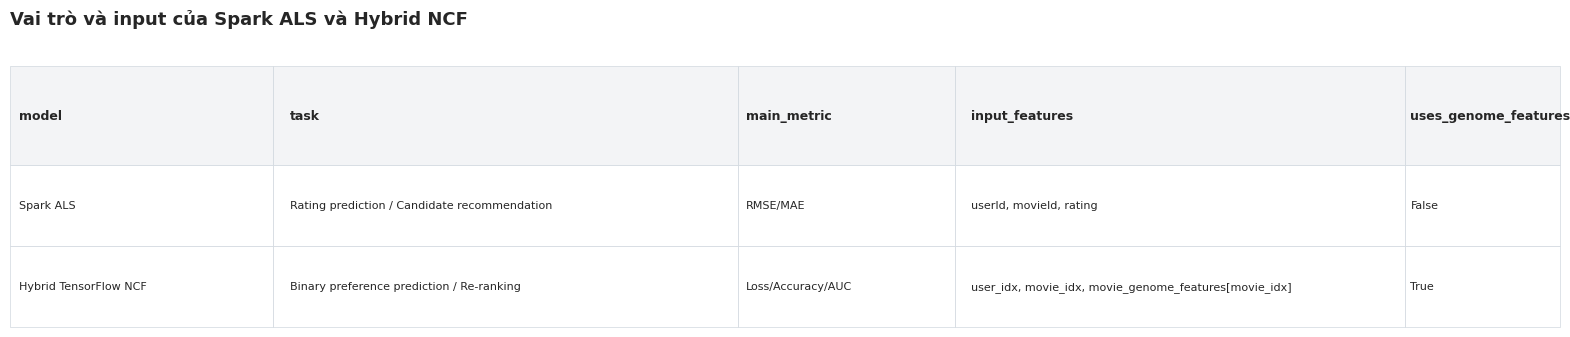

### Metric interpretation notes

,model,metric_group,optimization_meaning,reporting_note
0,Spark ALS,RMSE / MAE,Càng thấp càng tốt,Đánh giá sai số dự đoán rating. Phù hợp cho baseline collaborative filtering và candidate generation.
1,Hybrid TensorFlow NCF,Loss / Accuracy / AUC,Loss càng thấp; Accuracy/AUC càng cao,"Đánh giá xác suất user thích phim. Phù hợp cho bước reranking sử dụng user, movie và genome features."
2,Cảnh báo so sánh,Khác bài toán đánh giá,Không quy đổi trực tiếp,Không nên kết luận NCF tốt hơn ALS chỉ vì AUC cao hơn RMSE; hai metric thuộc hai bài toán khác nhau.


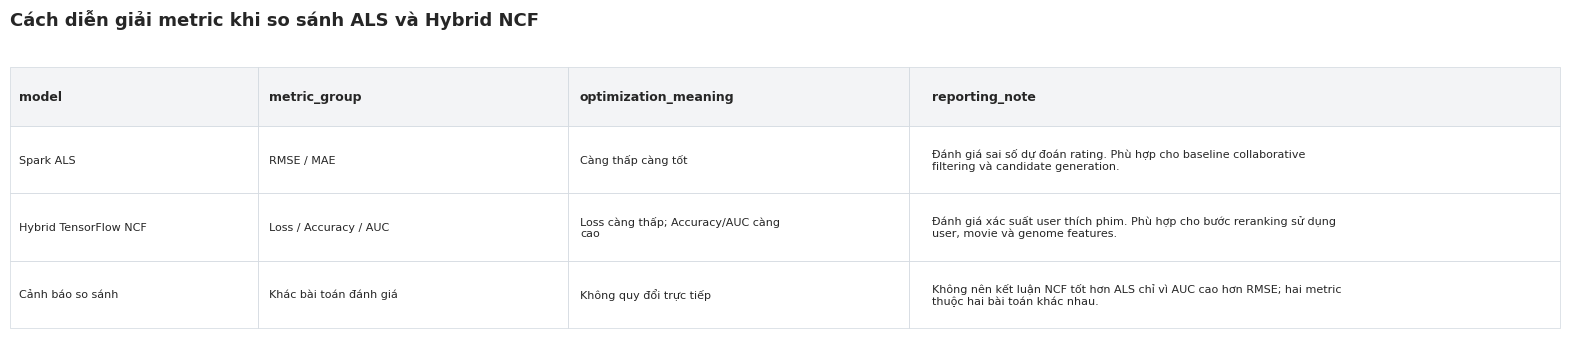

PosixPath('/workspace/outputs/reporting/reporting_layer_8_9_final_comparison_demo/figures/metric_interpretation_notes_table.png')

In [4]:
comparison_report_df = model_comparison_df.copy()
if len(comparison_report_df):
    # Normalize readable display values without mutating raw numeric columns too much.
    for col in ["rmse", "mae", "loss", "accuracy", "auc"]:
        if col in comparison_report_df.columns:
            comparison_report_df[f"{col}_display"] = comparison_report_df[col].apply(lambda x: human_float(x, 4))

    save_table(comparison_report_df, "model_comparison_enriched")
    display_df(comparison_report_df, "Model comparison from notebook 8", max_rows=10)

    visible_cols = [c for c in ["model", "task", "main_metric", "input_features", "uses_genome_features"] if c in comparison_report_df.columns]
    save_table_image(
        comparison_report_df[visible_cols],
        "model_comparison_role_table",
        "Vai trò và input của Spark ALS và Hybrid NCF",
        max_rows=10,
        wrap_width=36,
        font_size=8,
        scale_y=1.15,
        wrap_widths={"model": 24, "task": 52, "main_metric": 22, "input_features": 56, "uses_genome_features": 20},
        col_widths=[0.17, 0.30, 0.14, 0.29, 0.10] if len(visible_cols) == 5 else None,
        fig_width=20,
    )

metric_interpretation_df = pd.DataFrame([
    {
        "model": "Spark ALS",
        "metric_group": "RMSE / MAE",
        "optimization_meaning": "Càng thấp càng tốt",
        "reporting_note": "Đánh giá sai số dự đoán rating. Phù hợp cho baseline collaborative filtering và candidate generation.",
    },
    {
        "model": "Hybrid TensorFlow NCF",
        "metric_group": "Loss / Accuracy / AUC",
        "optimization_meaning": "Loss càng thấp; Accuracy/AUC càng cao",
        "reporting_note": "Đánh giá xác suất user thích phim. Phù hợp cho bước reranking sử dụng user, movie và genome features.",
    },
    {
        "model": "Cảnh báo so sánh",
        "metric_group": "Khác bài toán đánh giá",
        "optimization_meaning": "Không quy đổi trực tiếp",
        "reporting_note": "Không nên kết luận NCF tốt hơn ALS chỉ vì AUC cao hơn RMSE; hai metric thuộc hai bài toán khác nhau.",
    },
])

save_table(metric_interpretation_df, "metric_interpretation_notes")
display_df(metric_interpretation_df, "Metric interpretation notes", max_rows=10)
save_table_image(
    metric_interpretation_df,
    "metric_interpretation_notes_table",
    "Cách diễn giải metric khi so sánh ALS và Hybrid NCF",
    max_rows=10,
    wrap_width=42,
    font_size=8,
    scale_y=1.15,
    wrap_widths={"model": 24, "metric_group": 30, "optimization_meaning": 34, "reporting_note": 72},
    col_widths=[0.16, 0.20, 0.22, 0.42],
    fig_width=20,
)

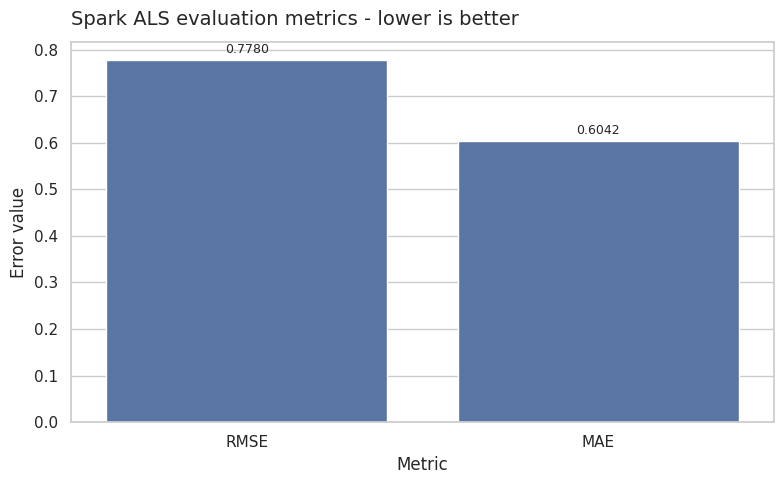

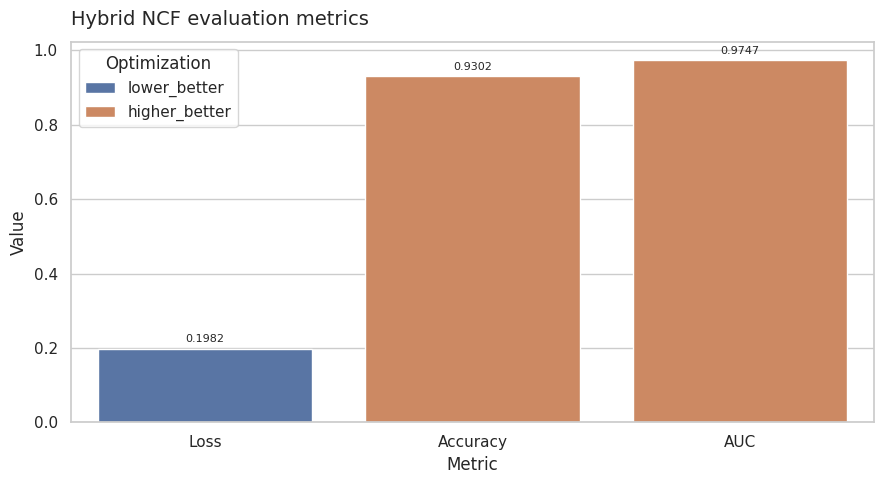

In [5]:
als_metric_plot_rows = []
for metric_name in ["rmse", "mae"]:
    value = get_metric(als_metrics, metric_name)
    if value is not None:
        als_metric_plot_rows.append({"metric": metric_name.upper(), "value": float(value)})
als_metric_plot_df = pd.DataFrame(als_metric_plot_rows)

if len(als_metric_plot_df):
    save_table(als_metric_plot_df, "als_metric_plot_data")
    plt.figure(figsize=(8, 5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=als_metric_plot_df, x="metric", y="value")
    else:
        ax = plt.gca(); ax.bar(als_metric_plot_df["metric"], als_metric_plot_df["value"])
    ax.set_title("Spark ALS evaluation metrics - lower is better", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Error value")
    for container in ax.containers:
        try:
            ax.bar_label(container, labels=[human_float(v, 4) for v in container.datavalues], padding=3, fontsize=9)
        except Exception:
            pass
    plt.tight_layout()
    save_figure("als_error_metrics_bar")
else:
    display(Markdown("_Không tìm thấy ALS RMSE/MAE để vẽ biểu đồ._"))

ncf_metric_plot_rows = []
for metric_name, label, direction in [
    ("loss", "Loss", "lower_better"),
    ("accuracy", "Accuracy", "higher_better"),
    ("binary_accuracy", "Binary accuracy", "higher_better"),
    ("auc", "AUC", "higher_better"),
]:
    value = get_metric(ncf_metrics, metric_name)
    if value is not None:
        ncf_metric_plot_rows.append({"metric": label, "value": float(value), "direction": direction})
ncf_metric_plot_df = pd.DataFrame(ncf_metric_plot_rows).drop_duplicates(subset=["metric"])

if len(ncf_metric_plot_df):
    save_table(ncf_metric_plot_df, "ncf_metric_plot_data")
    plt.figure(figsize=(9, 5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=ncf_metric_plot_df, x="metric", y="value", hue="direction", dodge=False)
        ax.legend(title="Optimization")
    else:
        ax = plt.gca(); ax.bar(ncf_metric_plot_df["metric"], ncf_metric_plot_df["value"])
    ax.set_title("Hybrid NCF evaluation metrics", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Value")
    for container in ax.containers:
        try:
            ax.bar_label(container, labels=[human_float(v, 4) for v in container.datavalues], padding=3, fontsize=8)
        except Exception:
            pass
    plt.tight_layout()
    save_figure("ncf_classification_metrics_bar")
else:
    display(Markdown("_Không tìm thấy NCF Loss/Accuracy/AUC để vẽ biểu đồ._"))

## 3. Dataset và output phục vụ final demo

Notebook 9 đã ghi lại `final_dataset_summary.csv` để cho thấy các nguồn dữ liệu và artifact cuối cùng đã được dùng trong demo khuyến nghị.

### Final dataset summary from notebook 9

,name,description,rows
0,ratings_raw,Toàn bộ rating gốc từ MovieLens 25M,25000095
1,movies_raw,Danh sách phim gốc,62423
2,genome_scores_raw,Movie genome relevance scores dùng làm content features cho Hybrid NCF,15584448
3,genome_tags_raw,Từ điển genome tag,1128
4,long_term_ratings,Rating của nhóm thành viên dài hạn sau tiền xử lý,10772371
5,als_user_factors,Số user có vector trong ALS model,25945
6,als_item_factors,Số phim có vector trong ALS model,53779
7,ncf_genome_feature_matrix,Số dòng movie feature dùng bởi Hybrid NCF,27099


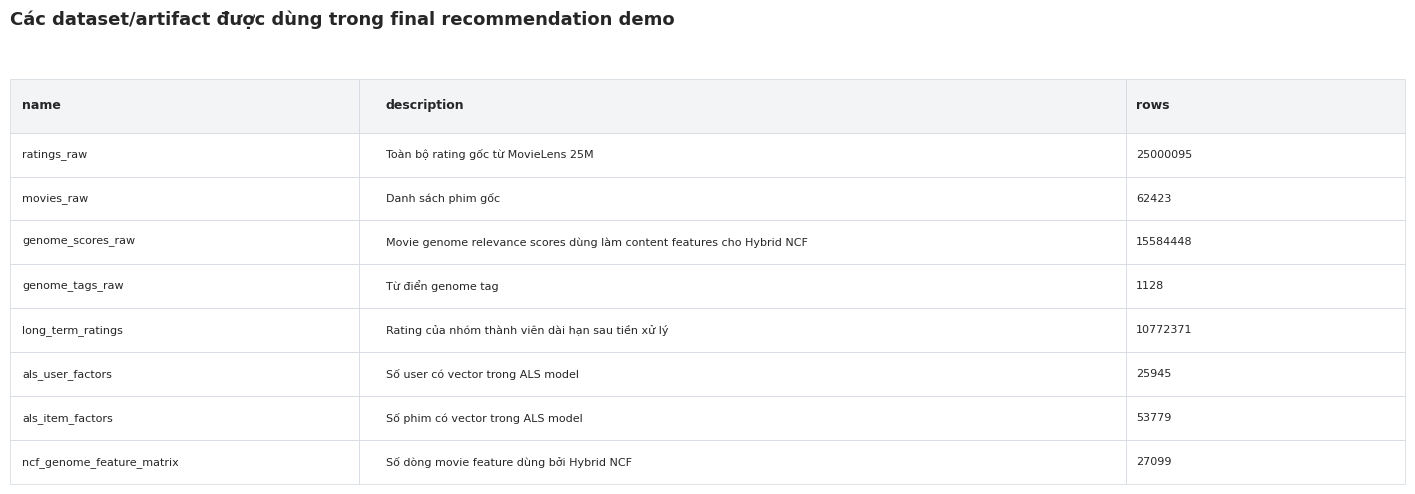

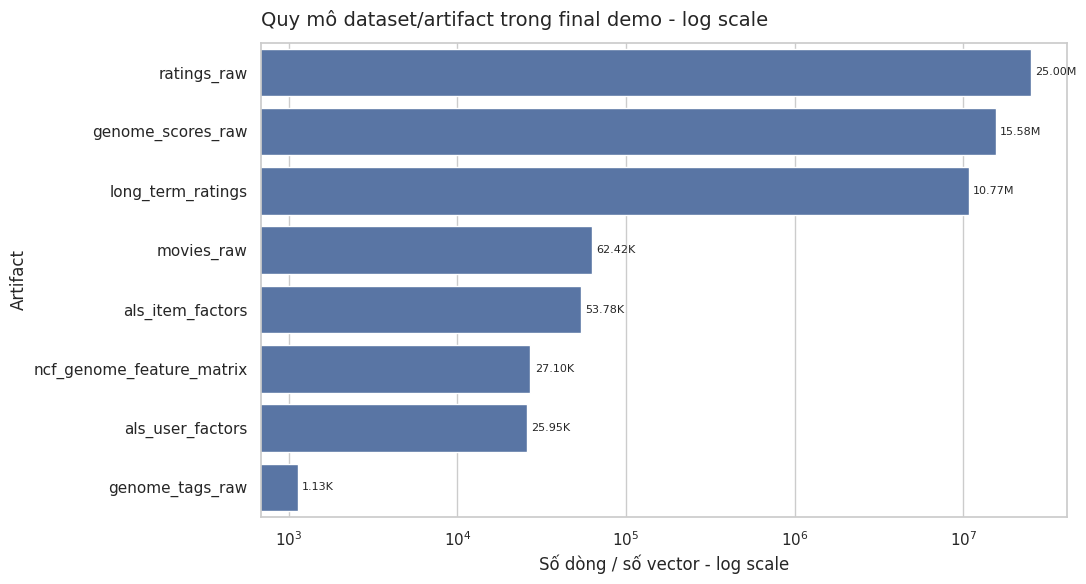

In [6]:
if len(final_dataset_summary_df):
    save_table(final_dataset_summary_df, "final_dataset_summary_report")
    display_df(final_dataset_summary_df, "Final dataset summary from notebook 9", max_rows=30)
    save_table_image(
        final_dataset_summary_df,
        "final_dataset_summary_table",
        "Các dataset/artifact được dùng trong final recommendation demo",
        max_rows=30,
        wrap_width=36,
        font_size=8,
        scale_y=1.15,
        wrap_widths={"name": 28, "description": 72, "rows": 18},
        col_widths=[0.25, 0.55, 0.20] if set(["name", "description", "rows"]).issubset(final_dataset_summary_df.columns) else None,
        fig_width=18,
    )

    if "rows" in final_dataset_summary_df.columns:
        plot_df = final_dataset_summary_df.copy()
        plot_df = plot_df[pd.to_numeric(plot_df["rows"], errors="coerce").notna()].copy()
        plot_df["rows"] = pd.to_numeric(plot_df["rows"], errors="coerce")
        if len(plot_df):
            plot_df = plot_df.sort_values("rows", ascending=False)
            plt.figure(figsize=(11, 6))
            y_col = "name" if "name" in plot_df.columns else plot_df.columns[0]
            if SEABORN_AVAILABLE:
                ax = sns.barplot(data=plot_df, y=y_col, x="rows")
            else:
                ax = plt.gca(); ax.barh(plot_df[y_col].astype(str), plot_df["rows"])
            ax.set_xscale("log")
            ax.set_title("Quy mô dataset/artifact trong final demo - log scale", fontsize=14, loc="left", pad=12)
            ax.set_xlabel("Số dòng / số vector - log scale")
            ax.set_ylabel("Artifact")
            for container in ax.containers:
                try:
                    ax.bar_label(container, labels=[compact_number(v) for v in container.datavalues], padding=3, fontsize=8)
                except Exception:
                    pass
            plt.tight_layout()
            save_figure("final_dataset_summary_rows_logscale")
else:
    display(Markdown("_Không tìm thấy final_dataset_summary.csv._"))

## 4. Sơ đồ luồng khuyến nghị cuối cùng

Sơ đồ dưới đây mô tả cách notebook 9 kết hợp hai mô hình: ALS tạo danh sách ứng viên ban đầu, sau đó Hybrid NCF dùng genome features để rerank danh sách đó.

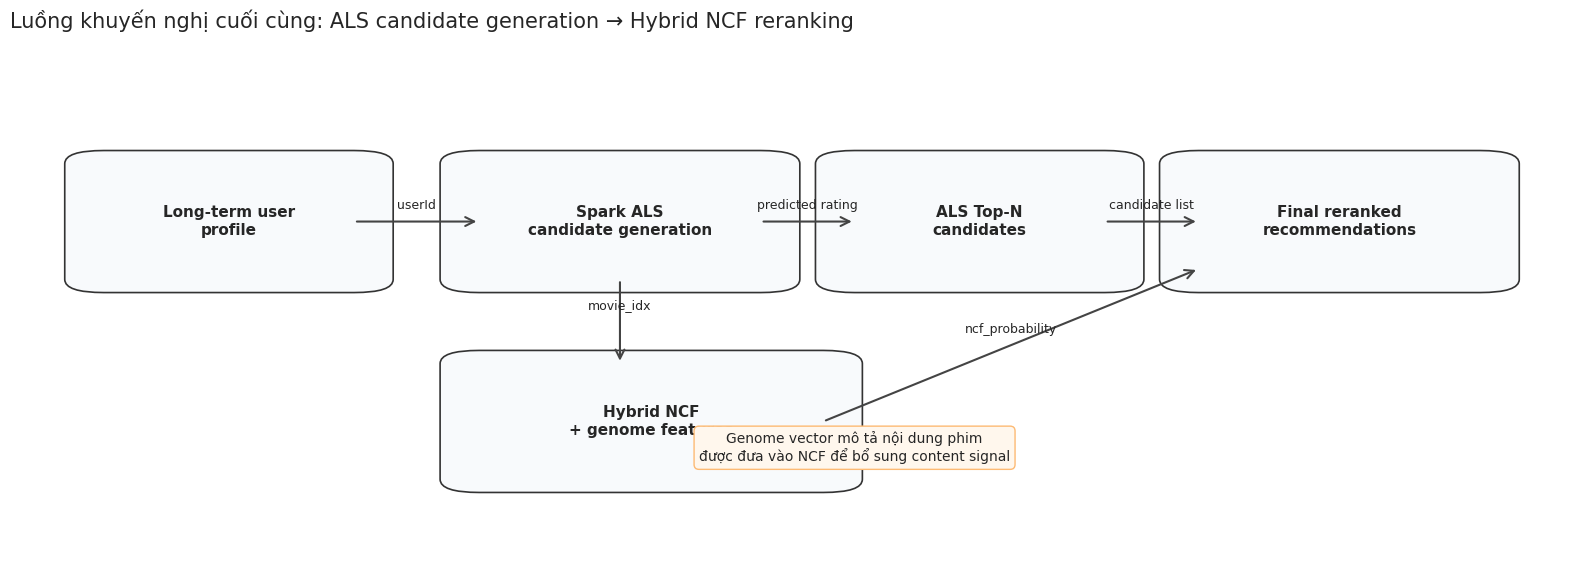

PosixPath('/workspace/outputs/reporting/reporting_layer_8_9_final_comparison_demo/figures/final_recommendation_flow_als_to_ncf.png')

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis("off")

nodes = [
    {"label": "Long-term user\nprofile", "xy": (0.06, 0.56), "w": 0.16, "h": 0.22},
    {"label": "Spark ALS\ncandidate generation", "xy": (0.30, 0.56), "w": 0.18, "h": 0.22},
    {"label": "ALS Top-N\ncandidates", "xy": (0.54, 0.56), "w": 0.16, "h": 0.22},
    {"label": "Hybrid NCF\n+ genome features", "xy": (0.30, 0.18), "w": 0.22, "h": 0.22},
    {"label": "Final reranked\nrecommendations", "xy": (0.76, 0.56), "w": 0.18, "h": 0.22},
]

for node in nodes:
    x, y = node["xy"]
    box = FancyBboxPatch(
        (x, y), node["w"], node["h"],
        boxstyle="round,pad=0.025,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#333333",
        facecolor="#F8FAFC",
    )
    ax.add_patch(box)
    ax.text(x + node["w"] / 2, y + node["h"] / 2, node["label"], ha="center", va="center", fontsize=11, fontweight="bold")

arrows = [
    ((0.22, 0.67), (0.30, 0.67), "userId"),
    ((0.48, 0.67), (0.54, 0.67), "predicted rating"),
    ((0.70, 0.67), (0.76, 0.67), "candidate list"),
    ((0.39, 0.56), (0.39, 0.40), "movie_idx"),
    ((0.52, 0.29), (0.76, 0.58), "ncf_probability"),
]

for start, end, label in arrows:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=16, linewidth=1.5, color="#444444"))
    mid_x = (start[0] + end[0]) / 2
    mid_y = (start[1] + end[1]) / 2
    ax.text(mid_x, mid_y + 0.03, label, ha="center", va="center", fontsize=9)

ax.text(
    0.54, 0.24,
    "Genome vector mô tả nội dung phim\nđược đưa vào NCF để bổ sung content signal",
    ha="center", va="center", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#FFF7ED", edgecolor="#FDBA74")
)

ax.set_title("Luồng khuyến nghị cuối cùng: ALS candidate generation → Hybrid NCF reranking", fontsize=15, loc="left", pad=14)
plt.tight_layout()
save_figure("final_recommendation_flow_als_to_ncf")

## 5. Kết quả demo cho một người dùng

Phần này đọc lại CSV đã sinh từ notebook 9: phim người dùng đã thích, top 10 từ ALS, và top 10 sau khi rerank bằng Hybrid NCF.

### Final demo summary

,demo_user_id,num_liked_movies_displayed,num_als_recommended_movies,num_hybrid_recommended_movies,overlap_liked_vs_als,overlap_liked_vs_hybrid,als_recommendation_output_file,hybrid_recommendation_output_file
0,3,10,10,10,0,0,/workspace/outputs/recommendations/user_3_als_top_10.csv,/workspace/outputs/recommendations/user_3_hybrid_als_ncf_top_10.csv


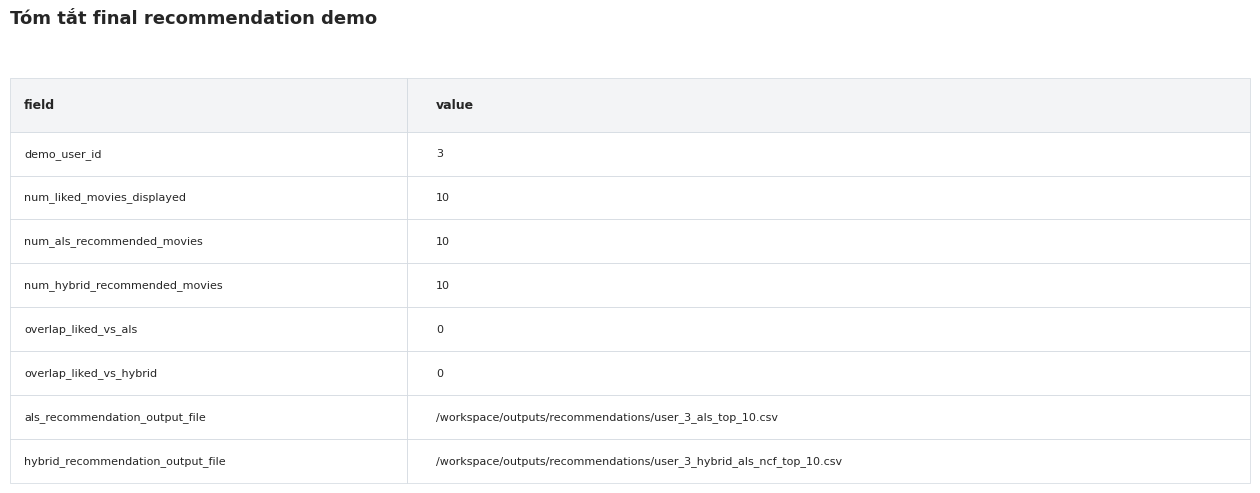

### Demo user liked movies

,rank,movieId,title,genres,rating,timestamp
0,1,541,Blade Runner (1982),Action|Sci-Fi|Thriller,5.000000,1439474625
1,2,1217,Ran (1985),Drama|War,5.000000,1439474455
2,3,741,Ghost in the Shell (Kôkaku kidôtai) (1995),Animation|Sci-Fi,5.000000,1484753808
3,4,778,Trainspotting (1996),Comedy|Crime|Drama,5.000000,1484753842
4,5,1213,Goodfellas (1990),Crime|Drama,5.000000,1484754156
5,6,858,"Godfather, The (1972)",Crime|Drama,5.000000,1439474389
6,7,214,Before the Rain (Pred dozhdot) (1994),Drama|War,5.000000,1484753888
7,8,924,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi,5.000000,1439474638
8,9,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,5.000000,1439474476
9,10,1148,Wallace & Gromit: The Wrong Trousers (1993),Animation|Children|Comedy|Crime,5.000000,1439474452


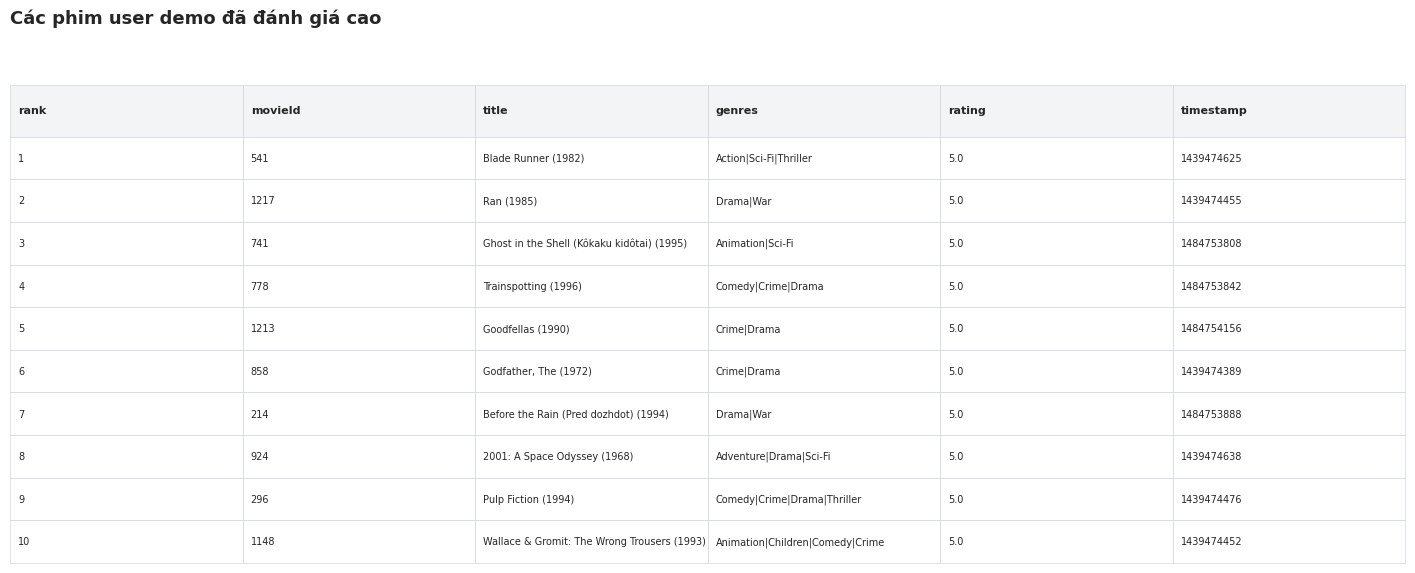

### ALS top 10 recommendations

,als_rank,movieId,title,genres,als_predicted_rating
0,1,203086,Truth and Justice (2019),Drama,5.646900
1,2,183947,NOFX Backstage Passport 2,(no genres listed),5.445400
2,3,184299,Freedom on My Mind (1994),Documentary,5.379400
3,4,165559,Ο Θανάσης στη χώρα της σφαλιάρας (1976),(no genres listed),5.353700
4,5,151615,Hello Stranger (2010),Drama,5.260700
5,6,196787,The Law and the Fist (1964),Drama|War,5.259800
6,7,166812,Seeing Red: Stories of American Communists (1983),(no genres listed),5.239200
7,8,157791,.hack Liminality In the Case of Kyoko Tohno,(no genres listed),5.237800
8,9,157787,.hack Liminality: In the Case of Mai Minase,(no genres listed),5.237800
9,10,192089,"National Theatre Live: One Man, Two Guvnors (2011)",Comedy,5.213900


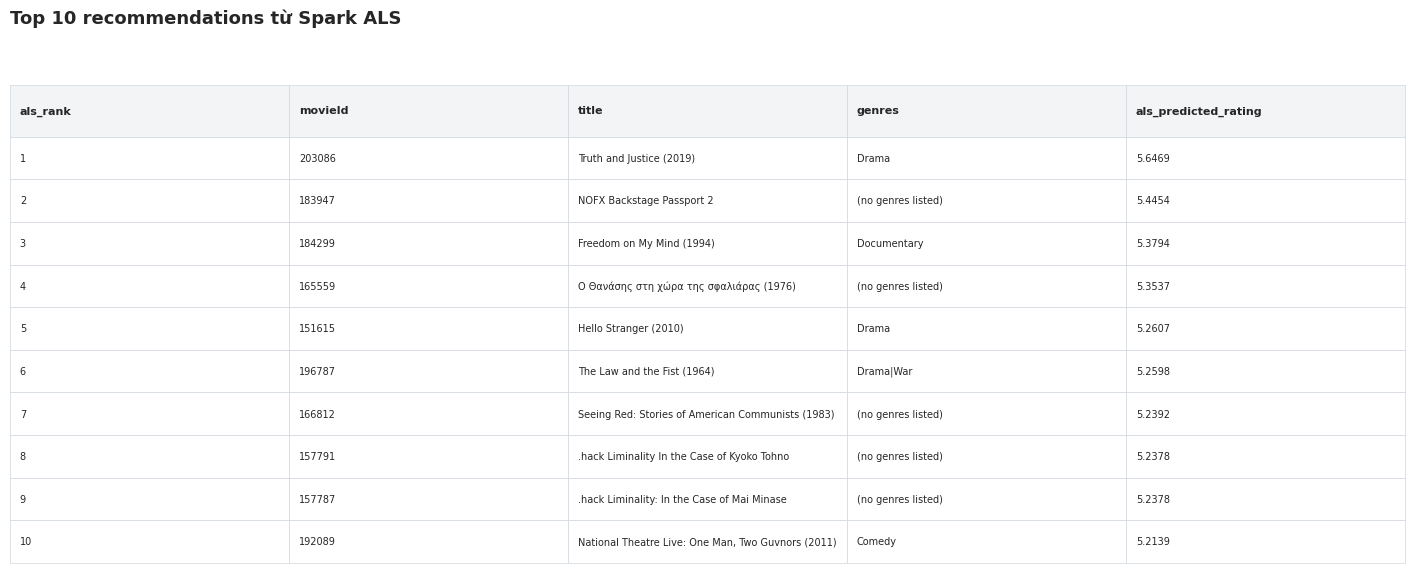

### Hybrid ALS + NCF top 10 recommendations

,hybrid_rank,movieId,title,genres,als_predicted_rating,ncf_probability
0,1,187947,Finger of God (2007),Documentary,5.146300,0.000000
1,2,138066,Last Day of Summer (2009),Comedy|Drama,4.918700,0.000000
2,3,165787,Lonesome Dove Church (2014),Western,5.130500,0.000000
3,4,93291,"Stone Left Unturned, A (Kovat miehet) (2000)",Comedy|Drama,5.016500,0.000000
4,5,87719,Living with Wolves (2005),Documentary,5.060700,0.000000
5,6,183947,NOFX Backstage Passport 2,(no genres listed),5.445400,0.000000
6,7,151615,Hello Stranger (2010),Drama,5.260700,0.000000
7,8,93991,"Eye for an Eye, An (Silmä silmästä) (1999)",Horror,5.062400,0.000000
8,9,199187,Hoaxed (2019),(no genres listed),4.964400,0.000000
9,10,180607,Whatever (1999),Comedy|Drama,4.960200,0.000000


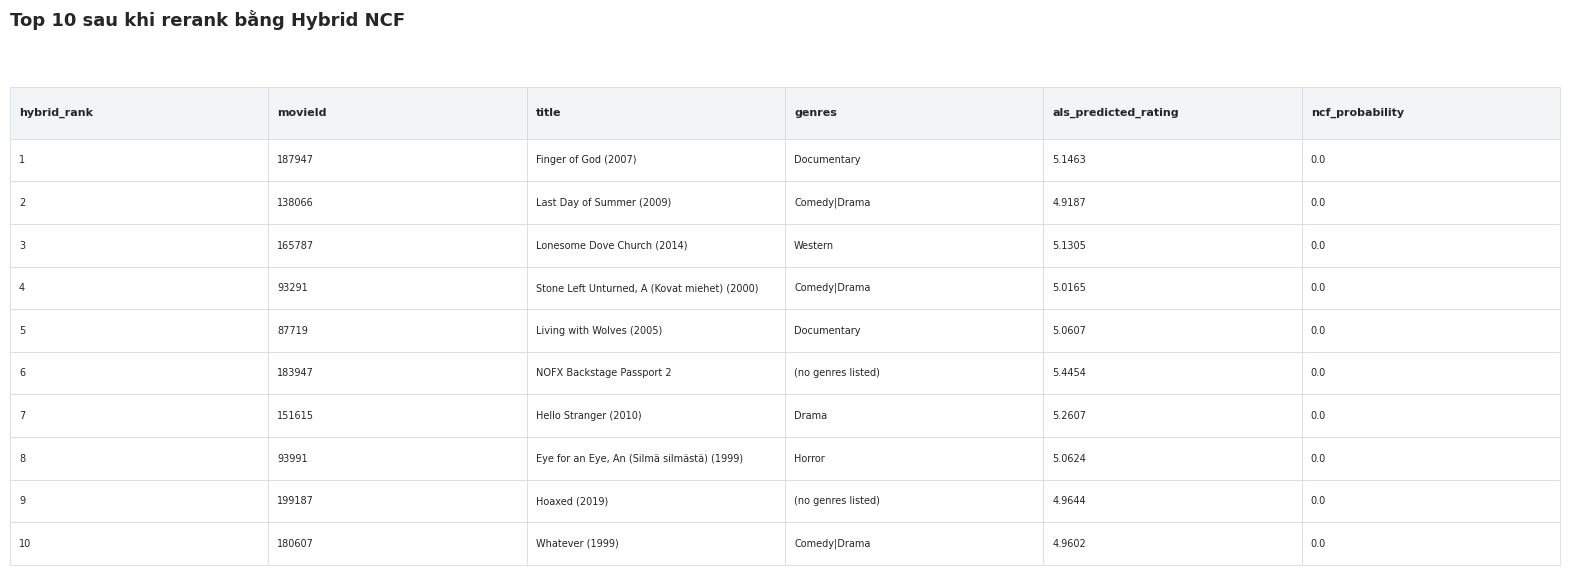

In [8]:
if demo_summary:
    demo_summary_df = pd.DataFrame([demo_summary])
    save_table(demo_summary_df, "final_demo_summary_report")
    display_df(demo_summary_df, "Final demo summary", max_rows=5)
    save_table_image(
        demo_summary_df.T.reset_index().rename(columns={"index": "field", 0: "value"}),
        "final_demo_summary_table",
        "Tóm tắt final recommendation demo",
        max_rows=30,
        wrap_width=48,
        font_size=8,
        scale_y=1.15,
        wrap_widths={"field": 36, "value": 80},
        col_widths=[0.32, 0.68],
        fig_width=16,
    )
else:
    display(Markdown("_Không tìm thấy final_demo_summary.json._"))

# Add rank columns for readable report tables.
if len(liked_movies_df):
    liked_report_df = liked_movies_df.copy().head(10)
    if "rating" in liked_report_df.columns:
        liked_report_df = liked_report_df.sort_values("rating", ascending=False).reset_index(drop=True)
    liked_report_df.insert(0, "rank", range(1, len(liked_report_df) + 1))
    keep_cols = [c for c in ["rank", "movieId", "title", "genres", "rating", "timestamp"] if c in liked_report_df.columns]
    liked_report_df = liked_report_df[keep_cols]
    save_table(liked_report_df, "demo_user_liked_movies_report")
    display_df(liked_report_df, "Demo user liked movies", max_rows=15)
    save_table_image(
        liked_report_df,
        "demo_user_liked_movies_table",
        "Các phim user demo đã đánh giá cao",
        max_rows=10,
        wrap_width=34,
        font_size=7,
        scale_y=1.15,
        wrap_widths={"rank": 8, "movieId": 12, "title": 52, "genres": 50, "rating": 10, "timestamp": 18},
        fig_width=18,
    )

if len(als_recommendations_df):
    als_report_df = als_recommendations_df.copy().head(10).reset_index(drop=True)
    als_report_df.insert(0, "als_rank", range(1, len(als_report_df) + 1))
    keep_cols = [c for c in ["als_rank", "movieId", "title", "genres", "als_predicted_rating"] if c in als_report_df.columns]
    als_report_df = als_report_df[keep_cols]
    if "als_predicted_rating" in als_report_df.columns:
        als_report_df["als_predicted_rating"] = pd.to_numeric(als_report_df["als_predicted_rating"], errors="coerce").round(4)
    save_table(als_report_df, "als_top10_recommendations_report")
    display_df(als_report_df, "ALS top 10 recommendations", max_rows=15)
    save_table_image(
        als_report_df,
        "als_top10_recommendations_table",
        "Top 10 recommendations từ Spark ALS",
        max_rows=10,
        wrap_width=34,
        font_size=7,
        scale_y=1.15,
        wrap_widths={"als_rank": 8, "movieId": 12, "title": 52, "genres": 50, "als_predicted_rating": 18},
        fig_width=18,
    )

if len(hybrid_recommendations_df):
    hybrid_report_df = hybrid_recommendations_df.copy().head(10).reset_index(drop=True)
    hybrid_report_df.insert(0, "hybrid_rank", range(1, len(hybrid_report_df) + 1))
    keep_cols = [c for c in ["hybrid_rank", "movieId", "title", "genres", "als_predicted_rating", "ncf_probability"] if c in hybrid_report_df.columns]
    hybrid_report_df = hybrid_report_df[keep_cols]
    for col in ["als_predicted_rating", "ncf_probability"]:
        if col in hybrid_report_df.columns:
            hybrid_report_df[col] = pd.to_numeric(hybrid_report_df[col], errors="coerce").round(4)
    save_table(hybrid_report_df, "hybrid_top10_recommendations_report")
    display_df(hybrid_report_df, "Hybrid ALS + NCF top 10 recommendations", max_rows=15)
    save_table_image(
        hybrid_report_df,
        "hybrid_top10_recommendations_table",
        "Top 10 sau khi rerank bằng Hybrid NCF",
        max_rows=10,
        wrap_width=34,
        font_size=7,
        scale_y=1.15,
        wrap_widths={"hybrid_rank": 8, "movieId": 12, "title": 52, "genres": 50, "als_predicted_rating": 18, "ncf_probability": 16},
        fig_width=20,
    )

### Recommendation overlap analysis

,metric,value,meaning
0,ALS Top10 size,10,Số phim trong danh sách top 10 của ALS.
1,Hybrid Top10 size,10,Số phim trong danh sách top 10 sau reranking.
2,Overlap ALS vs Hybrid,2,Số phim xuất hiện trong cả hai danh sách top 10.
3,ALS only,8,"Số phim chỉ có trong ALS top 10, bị thay đổi sau reranking."
4,Hybrid only,8,Số phim xuất hiện ở hybrid top 10 nhưng không nằm trong ALS top 10 đã lưu.
5,Liked ∩ ALS,0,Overlap giữa phim user từng thích và ALS recommendation.
6,Liked ∩ Hybrid,0,Overlap giữa phim user từng thích và Hybrid recommendation.


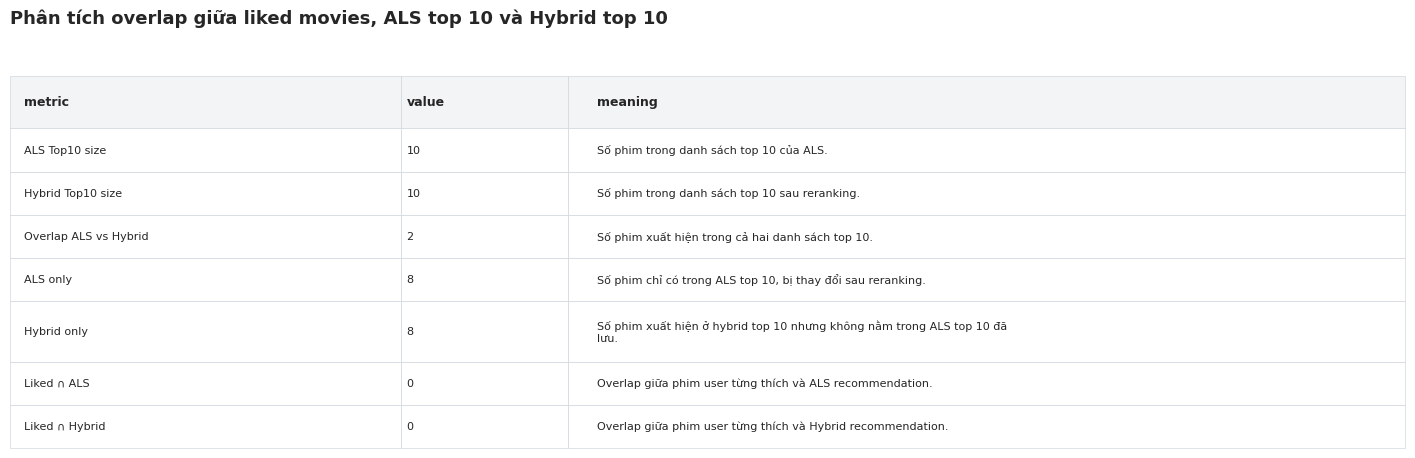

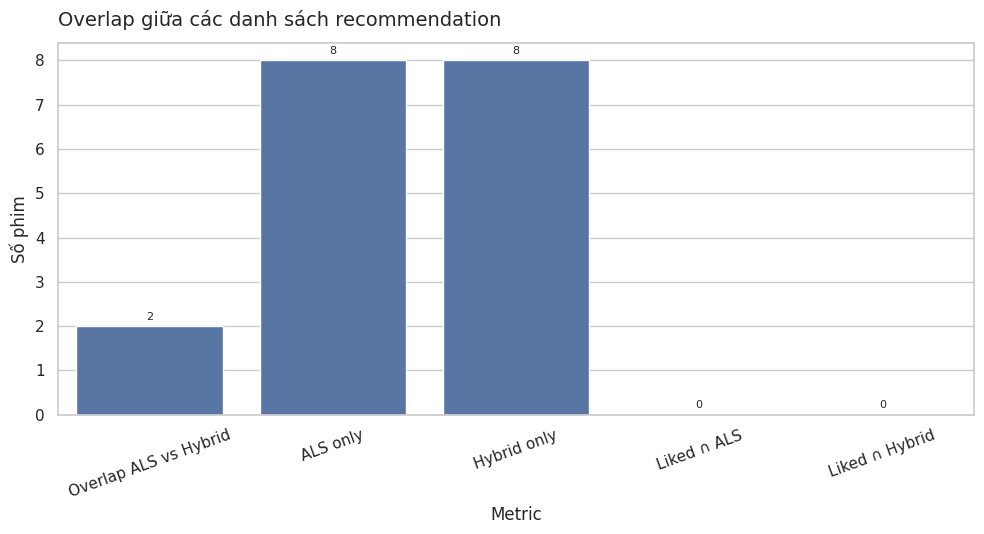

### Rank shift for movies common to ALS and Hybrid top 10

,movieId,title,als_rank,als_predicted_rating,hybrid_rank,ncf_probability,rank_delta_hybrid_minus_als
0,183947,NOFX Backstage Passport 2,2,5.445360,6,0.000000,4
1,151615,Hello Stranger (2010),5,5.260718,7,0.000000,2


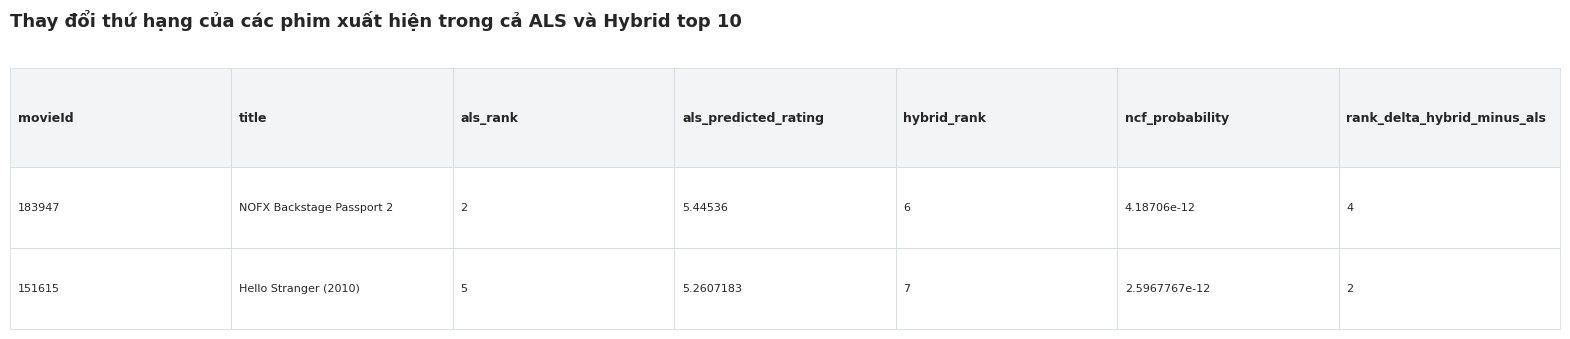

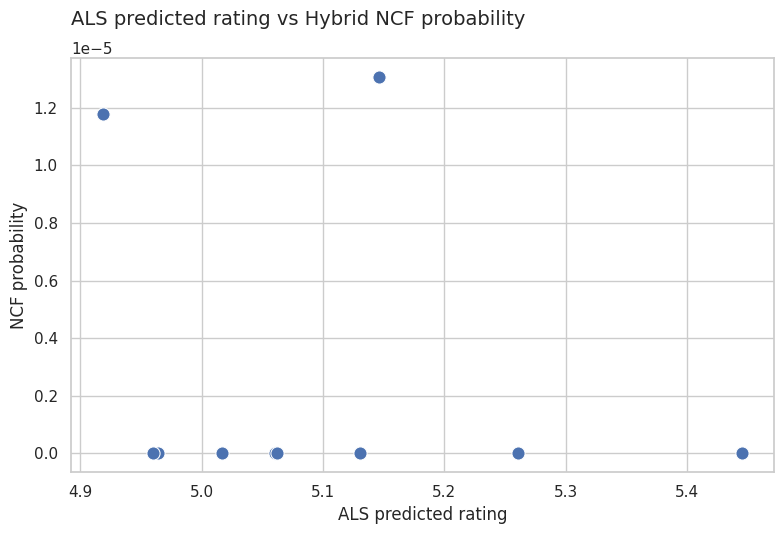

In [9]:
analysis_rows = []

liked_ids = set(liked_movies_df["movieId"].astype(int).tolist()) if len(liked_movies_df) and "movieId" in liked_movies_df.columns else set()
als_ids = set(als_recommendations_df["movieId"].astype(int).tolist()) if len(als_recommendations_df) and "movieId" in als_recommendations_df.columns else set()
hybrid_ids = set(hybrid_recommendations_df["movieId"].astype(int).tolist()) if len(hybrid_recommendations_df) and "movieId" in hybrid_recommendations_df.columns else set()

if als_ids or hybrid_ids or liked_ids:
    analysis_rows.extend([
        {"metric": "ALS Top10 size", "value": len(als_ids), "meaning": "Số phim trong danh sách top 10 của ALS."},
        {"metric": "Hybrid Top10 size", "value": len(hybrid_ids), "meaning": "Số phim trong danh sách top 10 sau reranking."},
        {"metric": "Overlap ALS vs Hybrid", "value": len(als_ids & hybrid_ids), "meaning": "Số phim xuất hiện trong cả hai danh sách top 10."},
        {"metric": "ALS only", "value": len(als_ids - hybrid_ids), "meaning": "Số phim chỉ có trong ALS top 10, bị thay đổi sau reranking."},
        {"metric": "Hybrid only", "value": len(hybrid_ids - als_ids), "meaning": "Số phim xuất hiện ở hybrid top 10 nhưng không nằm trong ALS top 10 đã lưu."},
        {"metric": "Liked ∩ ALS", "value": len(liked_ids & als_ids), "meaning": "Overlap giữa phim user từng thích và ALS recommendation."},
        {"metric": "Liked ∩ Hybrid", "value": len(liked_ids & hybrid_ids), "meaning": "Overlap giữa phim user từng thích và Hybrid recommendation."},
    ])

analysis_df = pd.DataFrame(analysis_rows)
if len(analysis_df):
    save_table(analysis_df, "recommendation_overlap_analysis")
    display_df(analysis_df, "Recommendation overlap analysis", max_rows=20)
    save_table_image(
        analysis_df,
        "recommendation_overlap_analysis_table",
        "Phân tích overlap giữa liked movies, ALS top 10 và Hybrid top 10",
        max_rows=20,
        wrap_width=40,
        font_size=8,
        scale_y=1.15,
        wrap_widths={"metric": 28, "value": 12, "meaning": 70},
        col_widths=[0.28, 0.12, 0.60],
        fig_width=18,
    )

    plot_df = analysis_df[analysis_df["metric"].isin(["Overlap ALS vs Hybrid", "ALS only", "Hybrid only", "Liked ∩ ALS", "Liked ∩ Hybrid"])].copy()
    if len(plot_df):
        plt.figure(figsize=(10, 5.5))
        if SEABORN_AVAILABLE:
            ax = sns.barplot(data=plot_df, x="metric", y="value")
        else:
            ax = plt.gca(); ax.bar(plot_df["metric"], plot_df["value"])
        ax.set_title("Overlap giữa các danh sách recommendation", fontsize=14, loc="left", pad=12)
        ax.set_xlabel("Metric")
        ax.set_ylabel("Số phim")
        ax.tick_params(axis="x", rotation=20)
        for container in ax.containers:
            try:
                ax.bar_label(container, labels=[human_int(v) for v in container.datavalues], padding=3, fontsize=8)
            except Exception:
                pass
        plt.tight_layout()
        save_figure("recommendation_overlap_bar")
else:
    display(Markdown("_Không đủ dữ liệu recommendation để phân tích overlap._"))

# Rank comparison for movies appearing in both saved top-10 lists.
if len(als_recommendations_df) and len(hybrid_recommendations_df) and "movieId" in als_recommendations_df.columns and "movieId" in hybrid_recommendations_df.columns:
    als_rank_df = als_recommendations_df.head(10).copy().reset_index(drop=True)
    als_rank_df["als_rank"] = range(1, len(als_rank_df) + 1)
    hyb_rank_df = hybrid_recommendations_df.head(10).copy().reset_index(drop=True)
    hyb_rank_df["hybrid_rank"] = range(1, len(hyb_rank_df) + 1)

    rank_cols_left = [c for c in ["movieId", "title", "als_rank", "als_predicted_rating"] if c in als_rank_df.columns]
    rank_cols_right = [c for c in ["movieId", "hybrid_rank", "ncf_probability"] if c in hyb_rank_df.columns]
    rank_shift_df = als_rank_df[rank_cols_left].merge(hyb_rank_df[rank_cols_right], on="movieId", how="inner")

    if len(rank_shift_df):
        rank_shift_df["rank_delta_hybrid_minus_als"] = rank_shift_df["hybrid_rank"] - rank_shift_df["als_rank"]
        save_table(rank_shift_df, "recommendation_rank_shift_common_movies")
        display_df(rank_shift_df, "Rank shift for movies common to ALS and Hybrid top 10", max_rows=20)
        save_table_image(
            rank_shift_df,
            "recommendation_rank_shift_common_movies_table",
            "Thay đổi thứ hạng của các phim xuất hiện trong cả ALS và Hybrid top 10",
            max_rows=20,
            wrap_width=32,
            font_size=8,
            scale_y=1.15,
            wrap_widths={"title": 58},
            fig_width=20,
        )

# Relationship between ALS score and NCF score in the final hybrid list.
if len(hybrid_recommendations_df) and {"als_predicted_rating", "ncf_probability"}.issubset(hybrid_recommendations_df.columns):
    score_df = hybrid_recommendations_df.copy()
    score_df["als_predicted_rating"] = pd.to_numeric(score_df["als_predicted_rating"], errors="coerce")
    score_df["ncf_probability"] = pd.to_numeric(score_df["ncf_probability"], errors="coerce")
    score_df = score_df.dropna(subset=["als_predicted_rating", "ncf_probability"])
    if len(score_df):
        plt.figure(figsize=(8, 5.5))
        if SEABORN_AVAILABLE:
            ax = sns.scatterplot(data=score_df, x="als_predicted_rating", y="ncf_probability", s=90)
        else:
            ax = plt.gca(); ax.scatter(score_df["als_predicted_rating"], score_df["ncf_probability"], s=90)
        ax.set_title("ALS predicted rating vs Hybrid NCF probability", fontsize=14, loc="left", pad=12)
        ax.set_xlabel("ALS predicted rating")
        ax.set_ylabel("NCF probability")
        plt.tight_layout()
        save_figure("als_score_vs_ncf_probability_scatter")

## 6. Inventory output cuối cùng

Bảng và biểu đồ dưới đây giúp viết phần nghiệm thu: chương trình đã tạo những file nào, nhóm output nào nhiều nhất, và các artifact nào có thể đưa vào báo cáo/slide.

### Final output inventory

,short_file,extension,size_kb,folder
0,avg_rating_by_genre.png,.png,86.600000,/workspace/outputs/figures
1,final_als_metrics.png,.png,42.130000,/workspace/outputs/figures
2,final_ncf_metrics.png,.png,39.390000,/workspace/outputs/figures
3,genre_distribution.png,.png,85.690000,/workspace/outputs/figures
4,long_term_user_distribution.png,.png,68.930000,/workspace/outputs/figures
5,model_comparison.png,.png,67.910000,/workspace/outputs/figures
6,ncf_training_loss.png,.png,96.900000,/workspace/outputs/figures
7,rating_distribution.png,.png,61.230000,/workspace/outputs/figures
8,ratings_by_year.png,.png,120.540000,/workspace/outputs/figures
9,ratings_per_movie_distribution.png,.png,73.730000,/workspace/outputs/figures


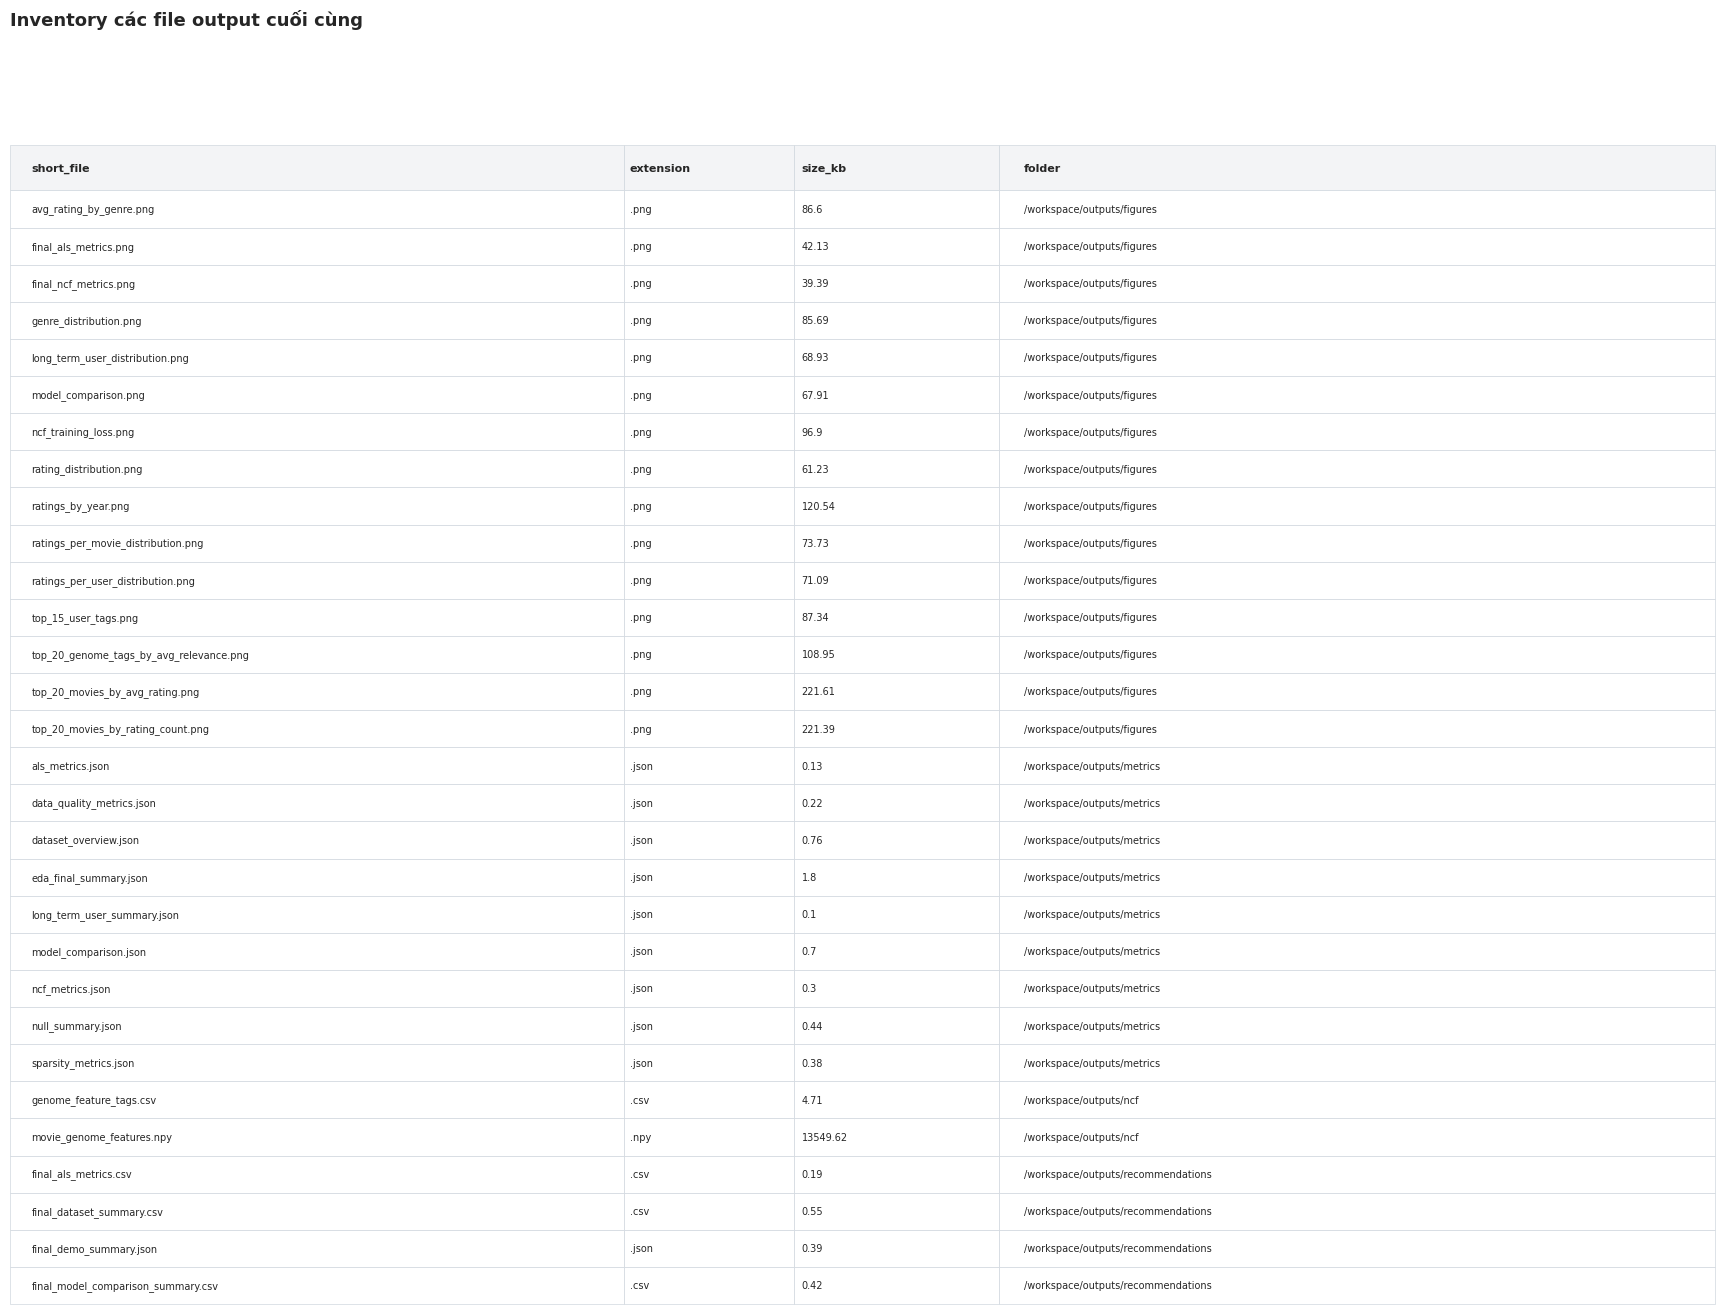

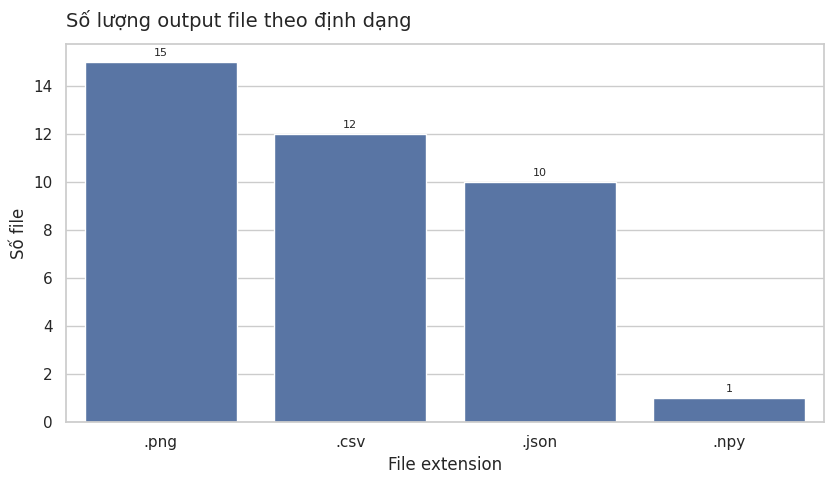

### Output size by folder

,folder,total_size_kb,files
2,/workspace/outputs/ncf,13554.330000,2
0,/workspace/outputs/figures,1453.430000,15
3,/workspace/outputs/recommendations,6.900000,12
1,/workspace/outputs/metrics,4.830000,9


In [10]:
if len(final_output_files_df):
    inventory_df = final_output_files_df.copy()
    if "file" in inventory_df.columns:
        inventory_df["extension"] = inventory_df["file"].apply(lambda x: Path(str(x)).suffix.lower() or "<none>")
        inventory_df["folder"] = inventory_df["file"].apply(lambda x: str(Path(str(x)).parent))
        inventory_df["short_file"] = inventory_df["file"].apply(lambda x: Path(str(x)).name)
    if "size_kb" in inventory_df.columns:
        inventory_df["size_kb"] = pd.to_numeric(inventory_df["size_kb"], errors="coerce")

    save_table(inventory_df, "final_output_inventory_enriched")
    display_df(inventory_df[[c for c in ["short_file", "extension", "size_kb", "folder"] if c in inventory_df.columns]], "Final output inventory", max_rows=50)

    save_table_image(
        inventory_df[[c for c in ["short_file", "extension", "size_kb", "folder"] if c in inventory_df.columns]].head(30),
        "final_output_inventory_table",
        "Inventory các file output cuối cùng",
        max_rows=30,
        wrap_width=38,
        font_size=7,
        scale_y=1.10,
        wrap_widths={"short_file": 54, "extension": 12, "size_kb": 14, "folder": 70},
        col_widths=[0.36, 0.10, 0.12, 0.42] if set(["short_file", "extension", "size_kb", "folder"]).issubset(inventory_df.columns) else None,
        fig_width=22,
    )

    if {"extension", "file"}.issubset(inventory_df.columns):
        ext_count_df = inventory_df.groupby("extension", as_index=False).agg(files=("file", "count"))
        ext_count_df = ext_count_df.sort_values("files", ascending=False)
        save_table(ext_count_df, "final_output_inventory_by_extension")
        plt.figure(figsize=(8.5, 5))
        if SEABORN_AVAILABLE:
            ax = sns.barplot(data=ext_count_df, x="extension", y="files")
        else:
            ax = plt.gca(); ax.bar(ext_count_df["extension"], ext_count_df["files"])
        ax.set_title("Số lượng output file theo định dạng", fontsize=14, loc="left", pad=12)
        ax.set_xlabel("File extension")
        ax.set_ylabel("Số file")
        for container in ax.containers:
            try:
                ax.bar_label(container, labels=[human_int(v) for v in container.datavalues], padding=3, fontsize=8)
            except Exception:
                pass
        plt.tight_layout()
        save_figure("final_output_inventory_by_extension_bar")

    if {"folder", "size_kb"}.issubset(inventory_df.columns):
        folder_size_df = inventory_df.groupby("folder", as_index=False).agg(total_size_kb=("size_kb", "sum"), files=("file", "count"))
        folder_size_df = folder_size_df.sort_values("total_size_kb", ascending=False).head(12)
        save_table(folder_size_df, "final_output_inventory_by_folder_size")
        display_df(folder_size_df, "Output size by folder", max_rows=20)
else:
    display(Markdown("_Không tìm thấy output inventory._"))

## 7. Storyboard và nội dung viết báo cáo

Phần này tổng hợp các luận điểm chính cho chương cuối: so sánh mô hình, demo khuyến nghị và nghiệm thu output.

### Final report storyboard

,report_section,main_message,evidence,recommended_visual
0,So sánh mô hình,Spark ALS và Hybrid NCF đóng hai vai trò khác nhau trong hệ thống khuyến nghị.,"ALS dùng RMSE=0.7780, MAE=0.6042; NCF dùng Loss=0.1982, Accuracy=0.9302, AUC=0.9747.","model_comparison_role_table.png, metric_interpretation_notes_table.png"
1,Luồng recommendation cuối,"ALS sinh candidate list, sau đó Hybrid NCF rerank bằng xác suất user thích phim.",Demo user=3; ALS top=10; Hybrid top=10.,final_recommendation_flow_als_to_ncf.png
2,Genome trong Hybrid NCF,Hybrid NCF khai thác content signal từ genome features để bổ sung cho collaborative signal.,uses_genome_features=True; genome_feature_dim=128.,"hybrid_top10_recommendations_table.png, als_score_vs_ncf_probability_scatter.png"
3,Kết quả demo,"Notebook 9 tạo được bảng phim user thích, danh sách ALS top 10 và danh sách Hybrid top 10.","Overlap liked-vs-ALS=0, liked-vs-Hybrid=0.","demo_user_liked_movies_table.png, als_top10_recommendations_table.png, hybrid_top10_recommendations_table.png"
4,Nghiệm thu output,"Pipeline cuối đã sinh metric, CSV recommendation, JSON summary và figure phục vụ báo cáo.",Inventory ghi nhận 38 output files.,"final_output_inventory_table.png, final_output_inventory_by_extension_bar.png"


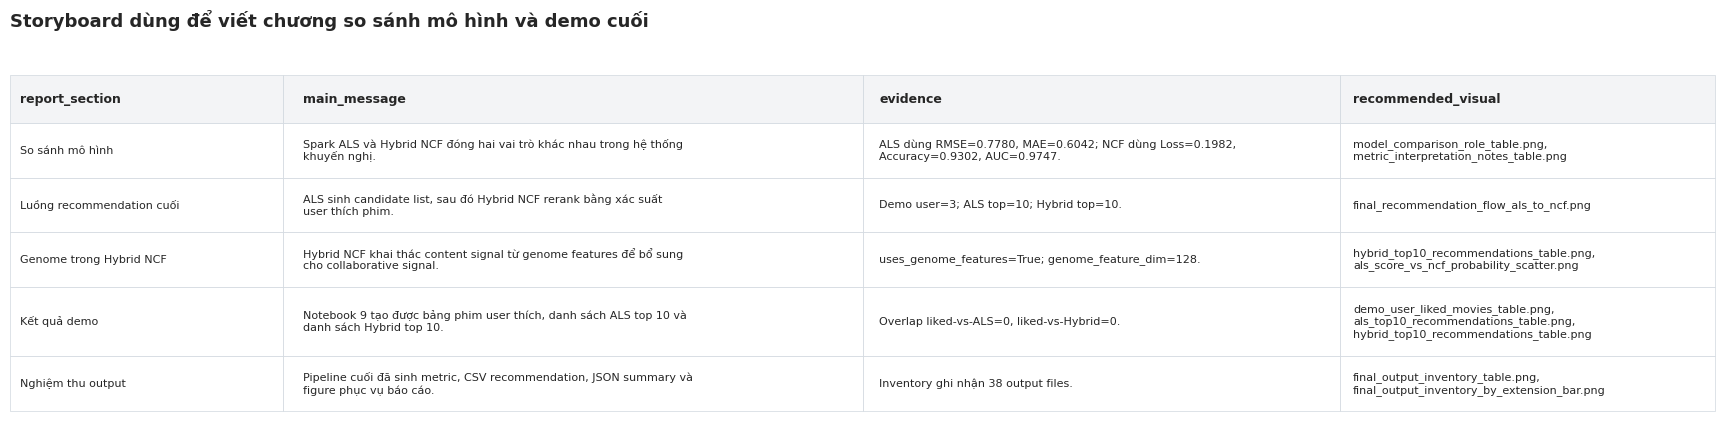

# Slide bullets — Model comparison & final recommendation demo

## Vai trò mô hình
- **Spark ALS**: baseline collaborative filtering, dùng để dự đoán rating và sinh candidate recommendation.
- **Hybrid TensorFlow NCF**: mô hình reranking, học xác suất user thích phim từ user/movie index và genome feature vector.
- Không so sánh trực tiếp RMSE/MAE với Accuracy/AUC vì đây là hai bài toán đánh giá khác nhau.

## Metric chính
- ALS: RMSE = **0.7780**, MAE = **0.6042**.
- NCF: Loss = **0.1982**, Accuracy = **0.9302**, AUC = **0.9747**.
- Hybrid NCF sử dụng genome features: **True**, genome feature dim = **128**.

## Demo recommendation
- Demo user: **3**.
- ALS sinh **10** recommendation, Hybrid NCF rerank thành **10** recommendation cuối.
- Overlap liked-vs-ALS = **0**, liked-vs-Hybrid = **0**.

## Output nghiệm thu
- Reporting layer tạo bảng, biểu đồ, storyboard và markdown để đưa vào báo cáo/slide.
- Inventory output cuối ghi nhận **38** files nếu `final_output_files.csv` tồn tại.

PosixPath('/workspace/outputs/reporting/reporting_layer_8_9_final_comparison_demo/markdown/final_comparison_demo_report_section.md')

In [11]:
als_rmse = get_metric(als_metrics, "rmse")
als_mae = get_metric(als_metrics, "mae")
ncf_loss = get_metric(ncf_metrics, "loss")
ncf_acc = get_metric(ncf_metrics, "accuracy", "binary_accuracy")
ncf_auc = get_metric(ncf_metrics, "auc")
uses_genome = get_metric(ncf_metrics, "uses_genome_features")
genome_dim = get_metric(ncf_metrics, "genome_feature_dim")

demo_user_id = demo_summary.get("demo_user_id")
als_top_size = demo_summary.get("num_als_recommended_movies") or (len(als_recommendations_df) if len(als_recommendations_df) else None)
hybrid_top_size = demo_summary.get("num_hybrid_recommended_movies") or (len(hybrid_recommendations_df) if len(hybrid_recommendations_df) else None)
liked_hybrid_overlap = demo_summary.get("overlap_liked_vs_hybrid")
liked_als_overlap = demo_summary.get("overlap_liked_vs_als")

storyboard_rows = [
    {
        "report_section": "So sánh mô hình",
        "main_message": "Spark ALS và Hybrid NCF đóng hai vai trò khác nhau trong hệ thống khuyến nghị.",
        "evidence": f"ALS dùng RMSE={human_float(als_rmse, 4)}, MAE={human_float(als_mae, 4)}; NCF dùng Loss={human_float(ncf_loss, 4)}, Accuracy={human_float(ncf_acc, 4)}, AUC={human_float(ncf_auc, 4)}.",
        "recommended_visual": "model_comparison_role_table.png, metric_interpretation_notes_table.png",
    },
    {
        "report_section": "Luồng recommendation cuối",
        "main_message": "ALS sinh candidate list, sau đó Hybrid NCF rerank bằng xác suất user thích phim.",
        "evidence": f"Demo user={demo_user_id}; ALS top={human_int(als_top_size)}; Hybrid top={human_int(hybrid_top_size)}.",
        "recommended_visual": "final_recommendation_flow_als_to_ncf.png",
    },
    {
        "report_section": "Genome trong Hybrid NCF",
        "main_message": "Hybrid NCF khai thác content signal từ genome features để bổ sung cho collaborative signal.",
        "evidence": f"uses_genome_features={uses_genome}; genome_feature_dim={human_int(genome_dim)}.",
        "recommended_visual": "hybrid_top10_recommendations_table.png, als_score_vs_ncf_probability_scatter.png",
    },
    {
        "report_section": "Kết quả demo",
        "main_message": "Notebook 9 tạo được bảng phim user thích, danh sách ALS top 10 và danh sách Hybrid top 10.",
        "evidence": f"Overlap liked-vs-ALS={human_int(liked_als_overlap)}, liked-vs-Hybrid={human_int(liked_hybrid_overlap)}.",
        "recommended_visual": "demo_user_liked_movies_table.png, als_top10_recommendations_table.png, hybrid_top10_recommendations_table.png",
    },
    {
        "report_section": "Nghiệm thu output",
        "main_message": "Pipeline cuối đã sinh metric, CSV recommendation, JSON summary và figure phục vụ báo cáo.",
        "evidence": f"Inventory ghi nhận {human_int(len(final_output_files_df))} output files." if len(final_output_files_df) else "Inventory chưa có dữ liệu.",
        "recommended_visual": "final_output_inventory_table.png, final_output_inventory_by_extension_bar.png",
    },
]

storyboard_df = pd.DataFrame(storyboard_rows)
save_table(storyboard_df, "final_report_storyboard")
display_df(storyboard_df, "Final report storyboard", max_rows=20)
save_table_image(
    storyboard_df,
    "final_report_storyboard_table",
    "Storyboard dùng để viết chương so sánh mô hình và demo cuối",
    max_rows=10,
    wrap_width=44,
    font_size=8,
    scale_y=1.15,
    wrap_widths={"report_section": 26, "main_message": 66, "evidence": 62, "recommended_visual": 50},
    col_widths=[0.16, 0.34, 0.28, 0.22],
    fig_width=22,
)

slide_bullets = f"""
# Slide bullets — Model comparison & final recommendation demo

## Vai trò mô hình
- **Spark ALS**: baseline collaborative filtering, dùng để dự đoán rating và sinh candidate recommendation.
- **Hybrid TensorFlow NCF**: mô hình reranking, học xác suất user thích phim từ user/movie index và genome feature vector.
- Không so sánh trực tiếp RMSE/MAE với Accuracy/AUC vì đây là hai bài toán đánh giá khác nhau.

## Metric chính
- ALS: RMSE = **{human_float(als_rmse, 4)}**, MAE = **{human_float(als_mae, 4)}**.
- NCF: Loss = **{human_float(ncf_loss, 4)}**, Accuracy = **{human_float(ncf_acc, 4)}**, AUC = **{human_float(ncf_auc, 4)}**.
- Hybrid NCF sử dụng genome features: **{uses_genome}**, genome feature dim = **{human_int(genome_dim)}**.

## Demo recommendation
- Demo user: **{demo_user_id if demo_user_id is not None else 'N/A'}**.
- ALS sinh **{human_int(als_top_size)}** recommendation, Hybrid NCF rerank thành **{human_int(hybrid_top_size)}** recommendation cuối.
- Overlap liked-vs-ALS = **{human_int(liked_als_overlap)}**, liked-vs-Hybrid = **{human_int(liked_hybrid_overlap)}**.

## Output nghiệm thu
- Reporting layer tạo bảng, biểu đồ, storyboard và markdown để đưa vào báo cáo/slide.
- Inventory output cuối ghi nhận **{human_int(len(final_output_files_df))}** files nếu `final_output_files.csv` tồn tại.
""".strip()

save_markdown(slide_bullets, MARKDOWN_DIR / "final_comparison_demo_slide_bullets.md")
display(Markdown(slide_bullets))

report_section = f"""
# Chương báo cáo — So sánh mô hình và demo khuyến nghị cuối cùng

Trong giai đoạn cuối, hệ thống sử dụng hai mô hình với vai trò bổ trợ nhau. Spark ALS được dùng như mô hình collaborative filtering nền tảng để học latent factor từ lịch sử rating và sinh danh sách ứng viên khuyến nghị. Hybrid TensorFlow NCF được dùng ở bước reranking, trong đó mô hình học xác suất người dùng thích một bộ phim dựa trên user index, movie index và vector đặc trưng nội dung từ MovieLens genome.

Kết quả đánh giá cần được diễn giải theo đúng bản chất từng bài toán. ALS được đánh giá bằng RMSE và MAE vì mô hình dự đoán giá trị rating liên tục. Trong khi đó, Hybrid NCF được đánh giá bằng Loss, Accuracy và AUC vì mô hình dự đoán nhãn thích/không thích hoặc xác suất preference. Do đó, không nên so sánh trực tiếp RMSE/MAE với Accuracy/AUC như cùng một thang đo duy nhất.

Trong notebook demo cuối, hệ thống chọn một người dùng hợp lệ từ ALS model, hiển thị các phim người dùng đã đánh giá cao, sinh danh sách top recommendation bằng ALS, sau đó dùng Hybrid NCF để rerank lại các candidate. Kết quả cuối cùng được lưu thành CSV và JSON summary trong thư mục `/workspace/outputs/recommendations`, phục vụ nghiệm thu và trình bày báo cáo.
""".strip()

save_markdown(report_section, MARKDOWN_DIR / "final_comparison_demo_report_section.md")

### Reporting layer manifest summary

,asset_type,count
0,figures,18
1,tables,16
2,metrics_json,2
3,markdown,2


### Preview: generated figures

**model_comparison_role_table**

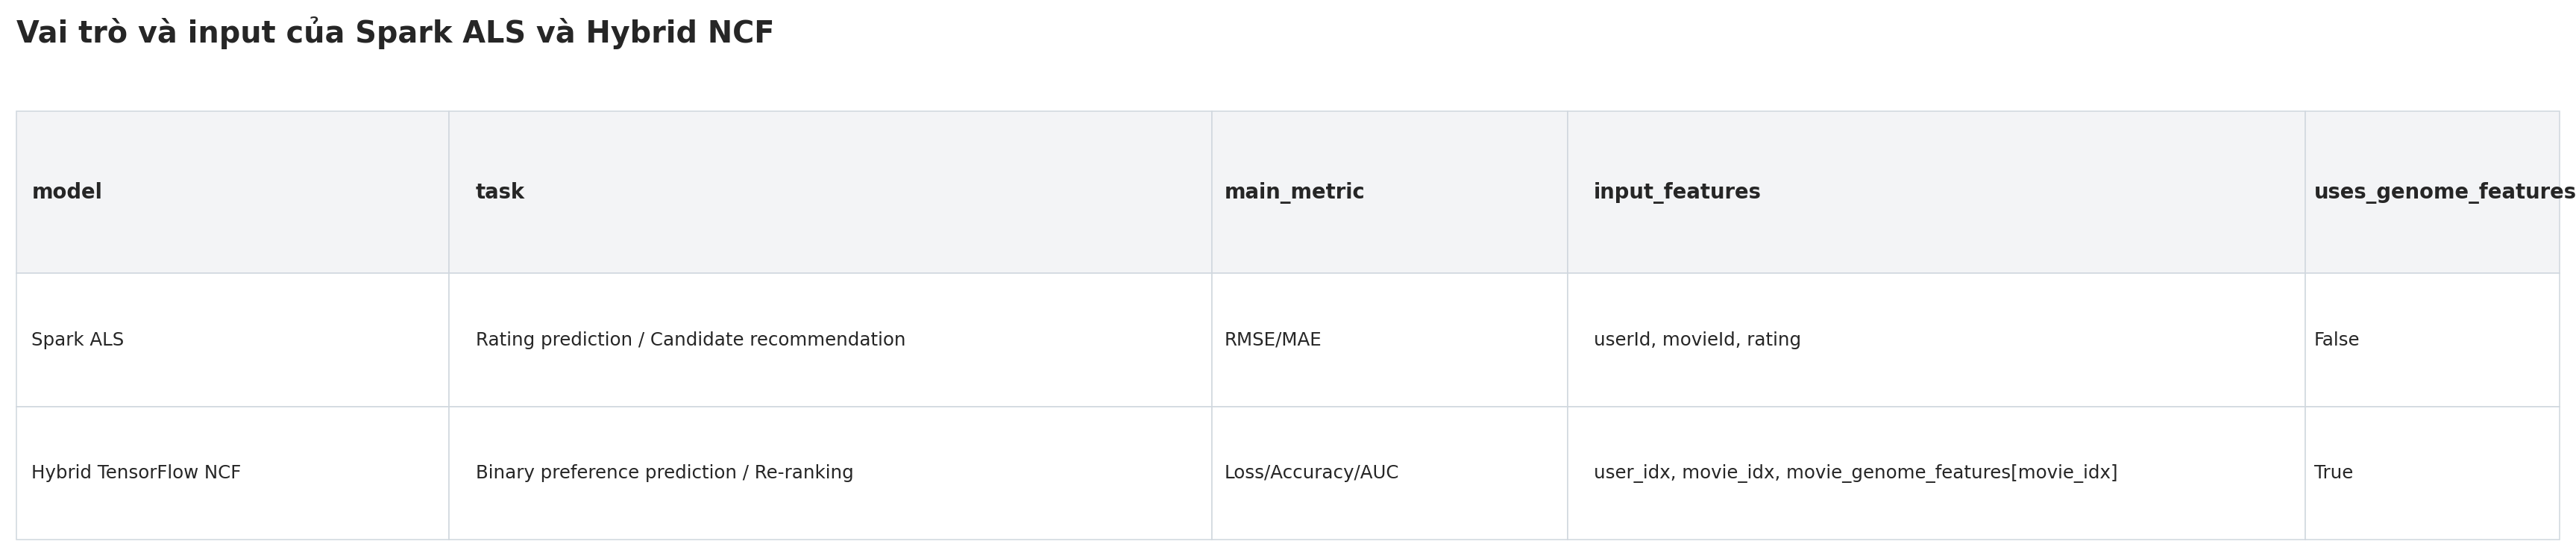

**als_error_metrics_bar**

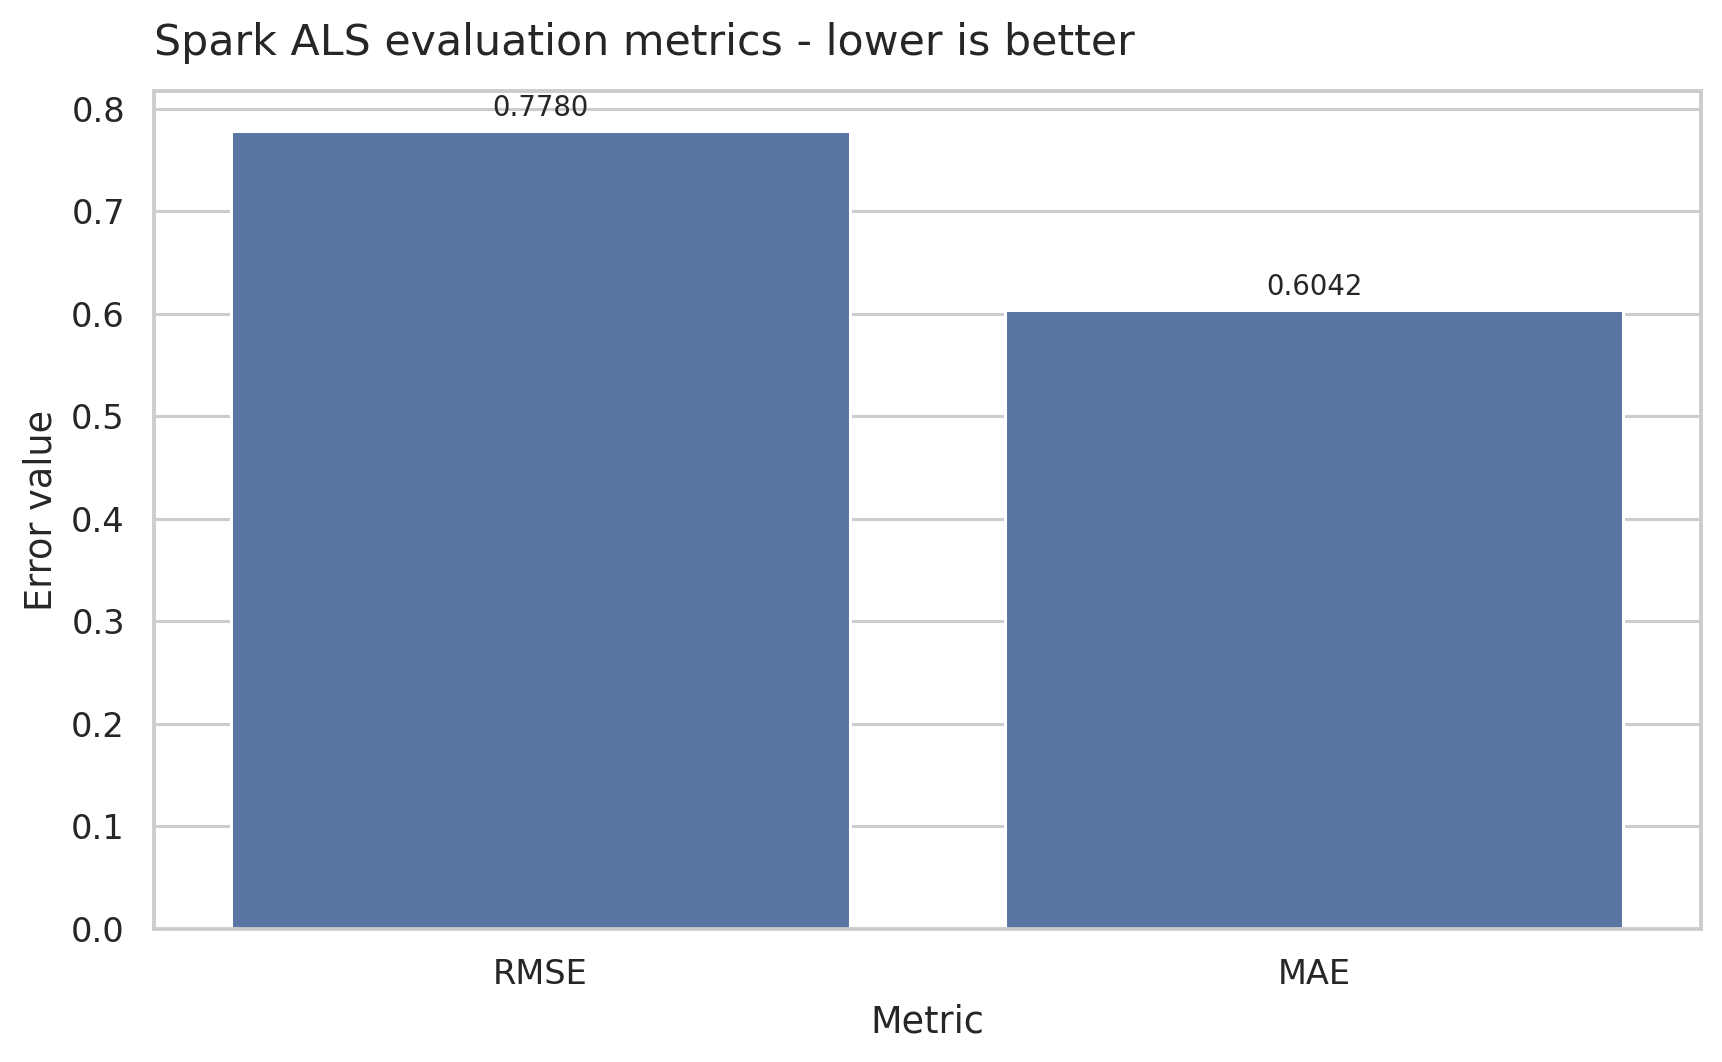

**ncf_classification_metrics_bar**

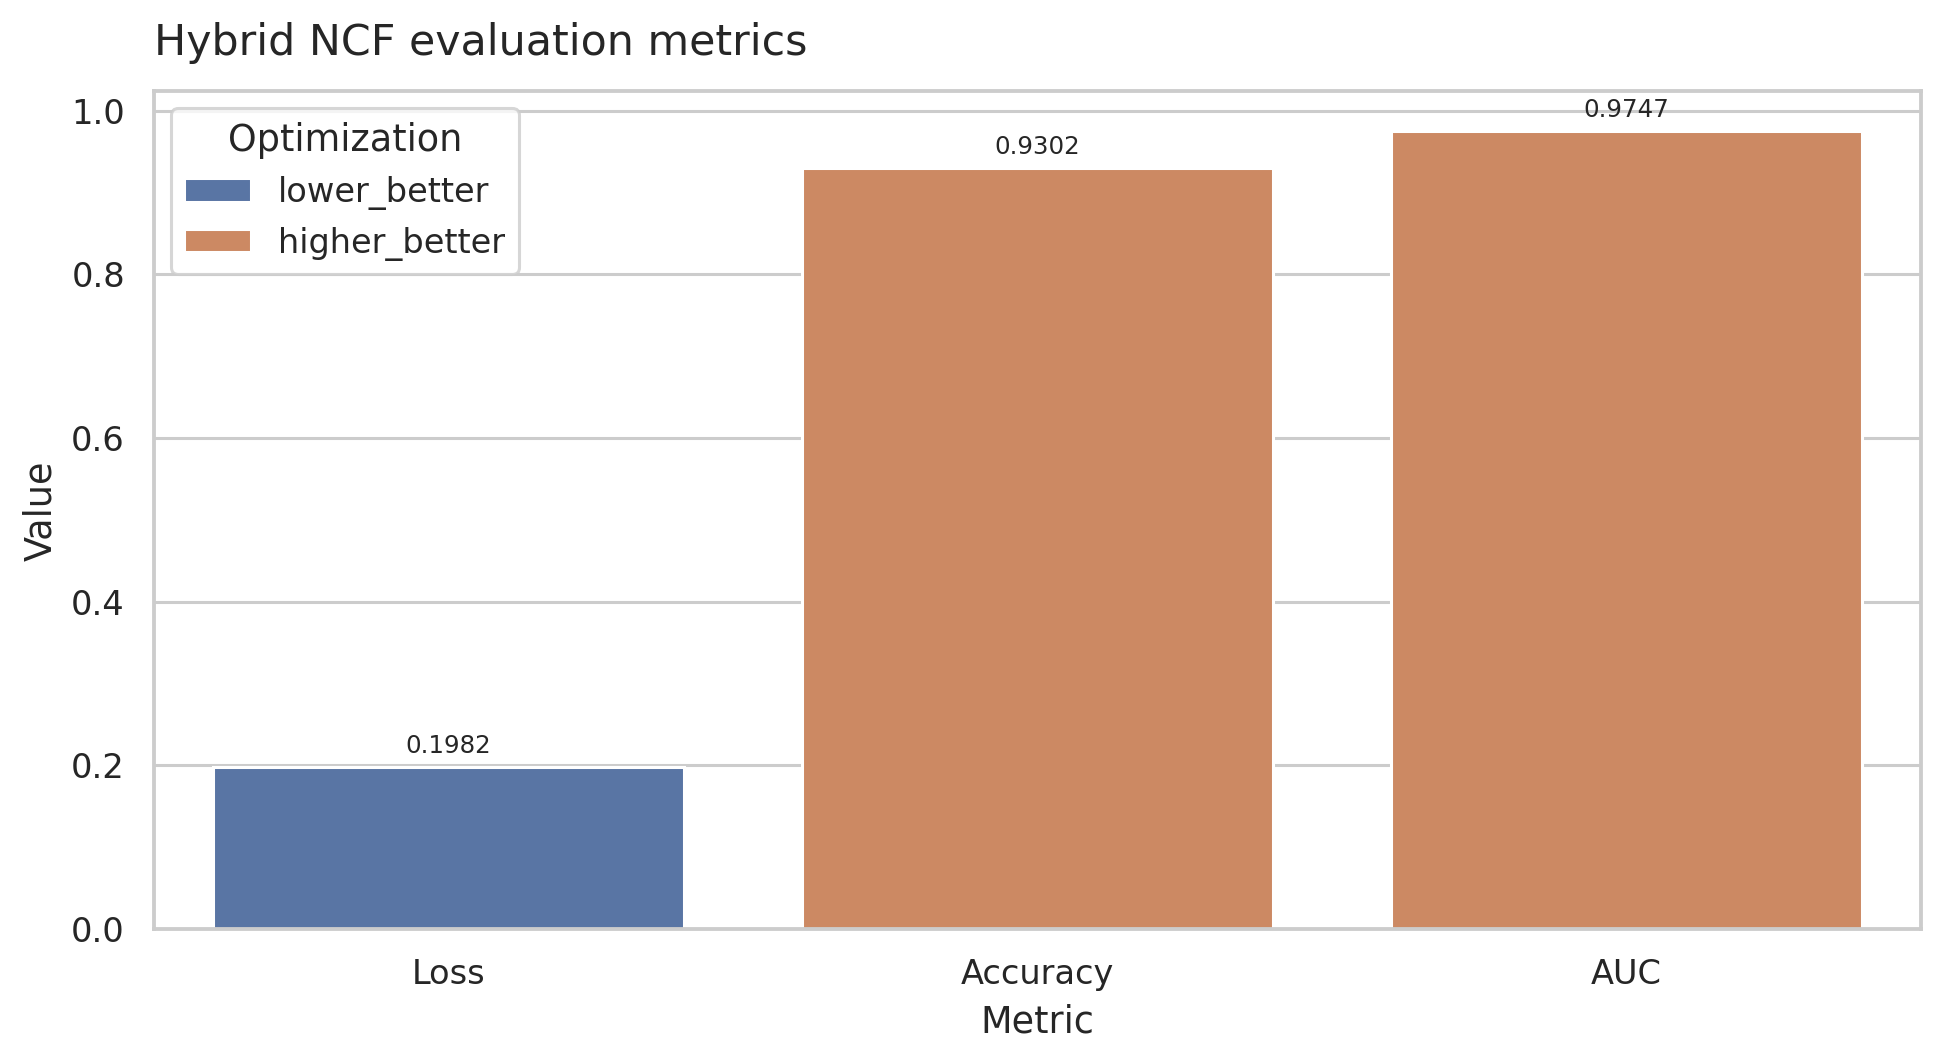

**final_dataset_summary_rows_logscale**

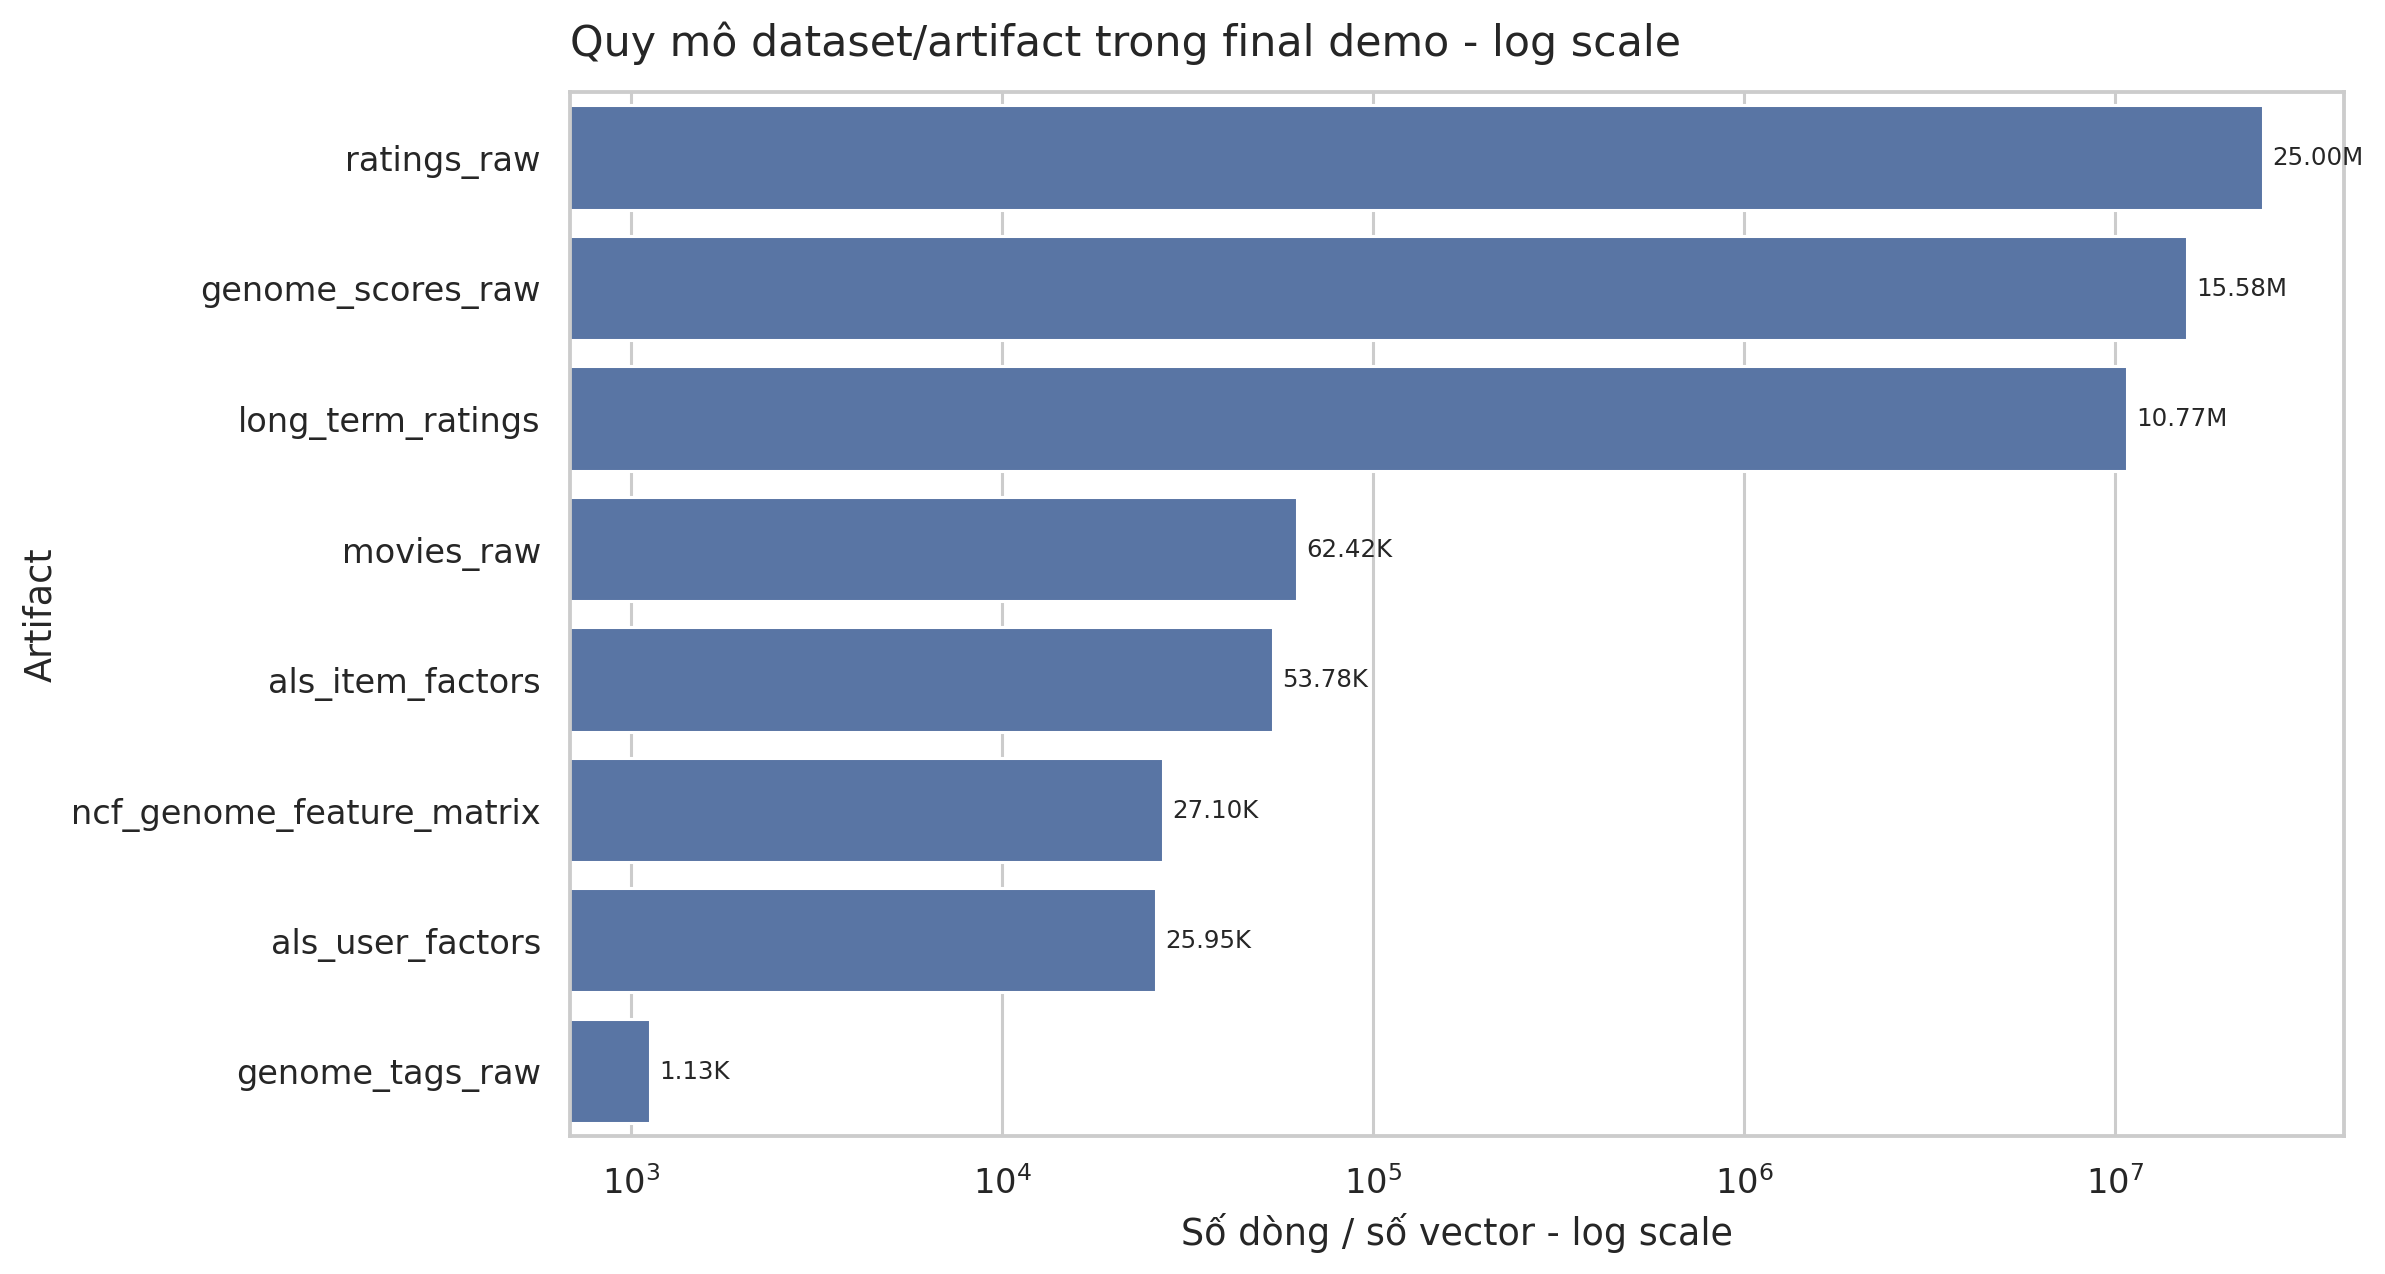

**final_recommendation_flow_als_to_ncf**

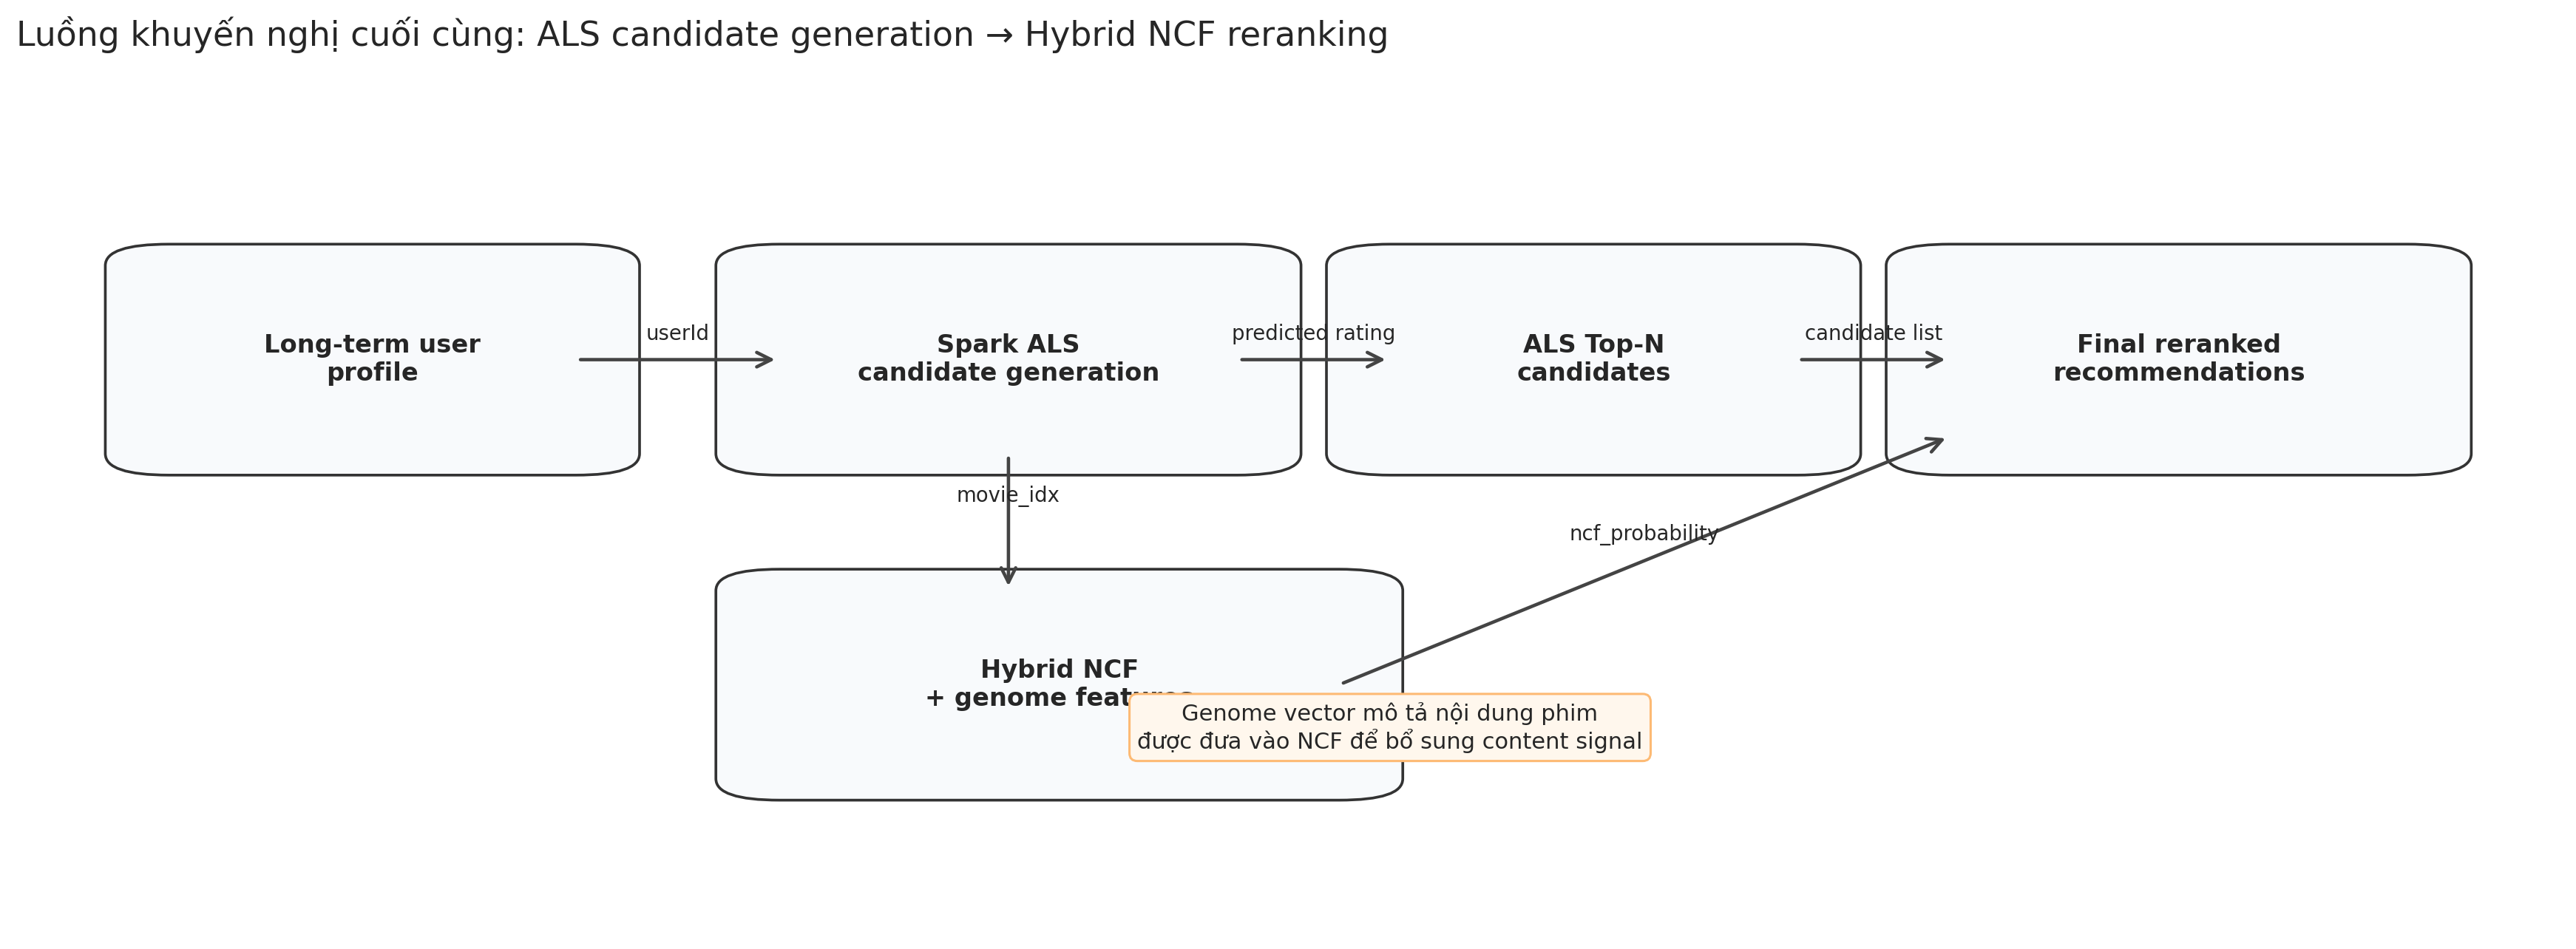

**recommendation_overlap_bar**

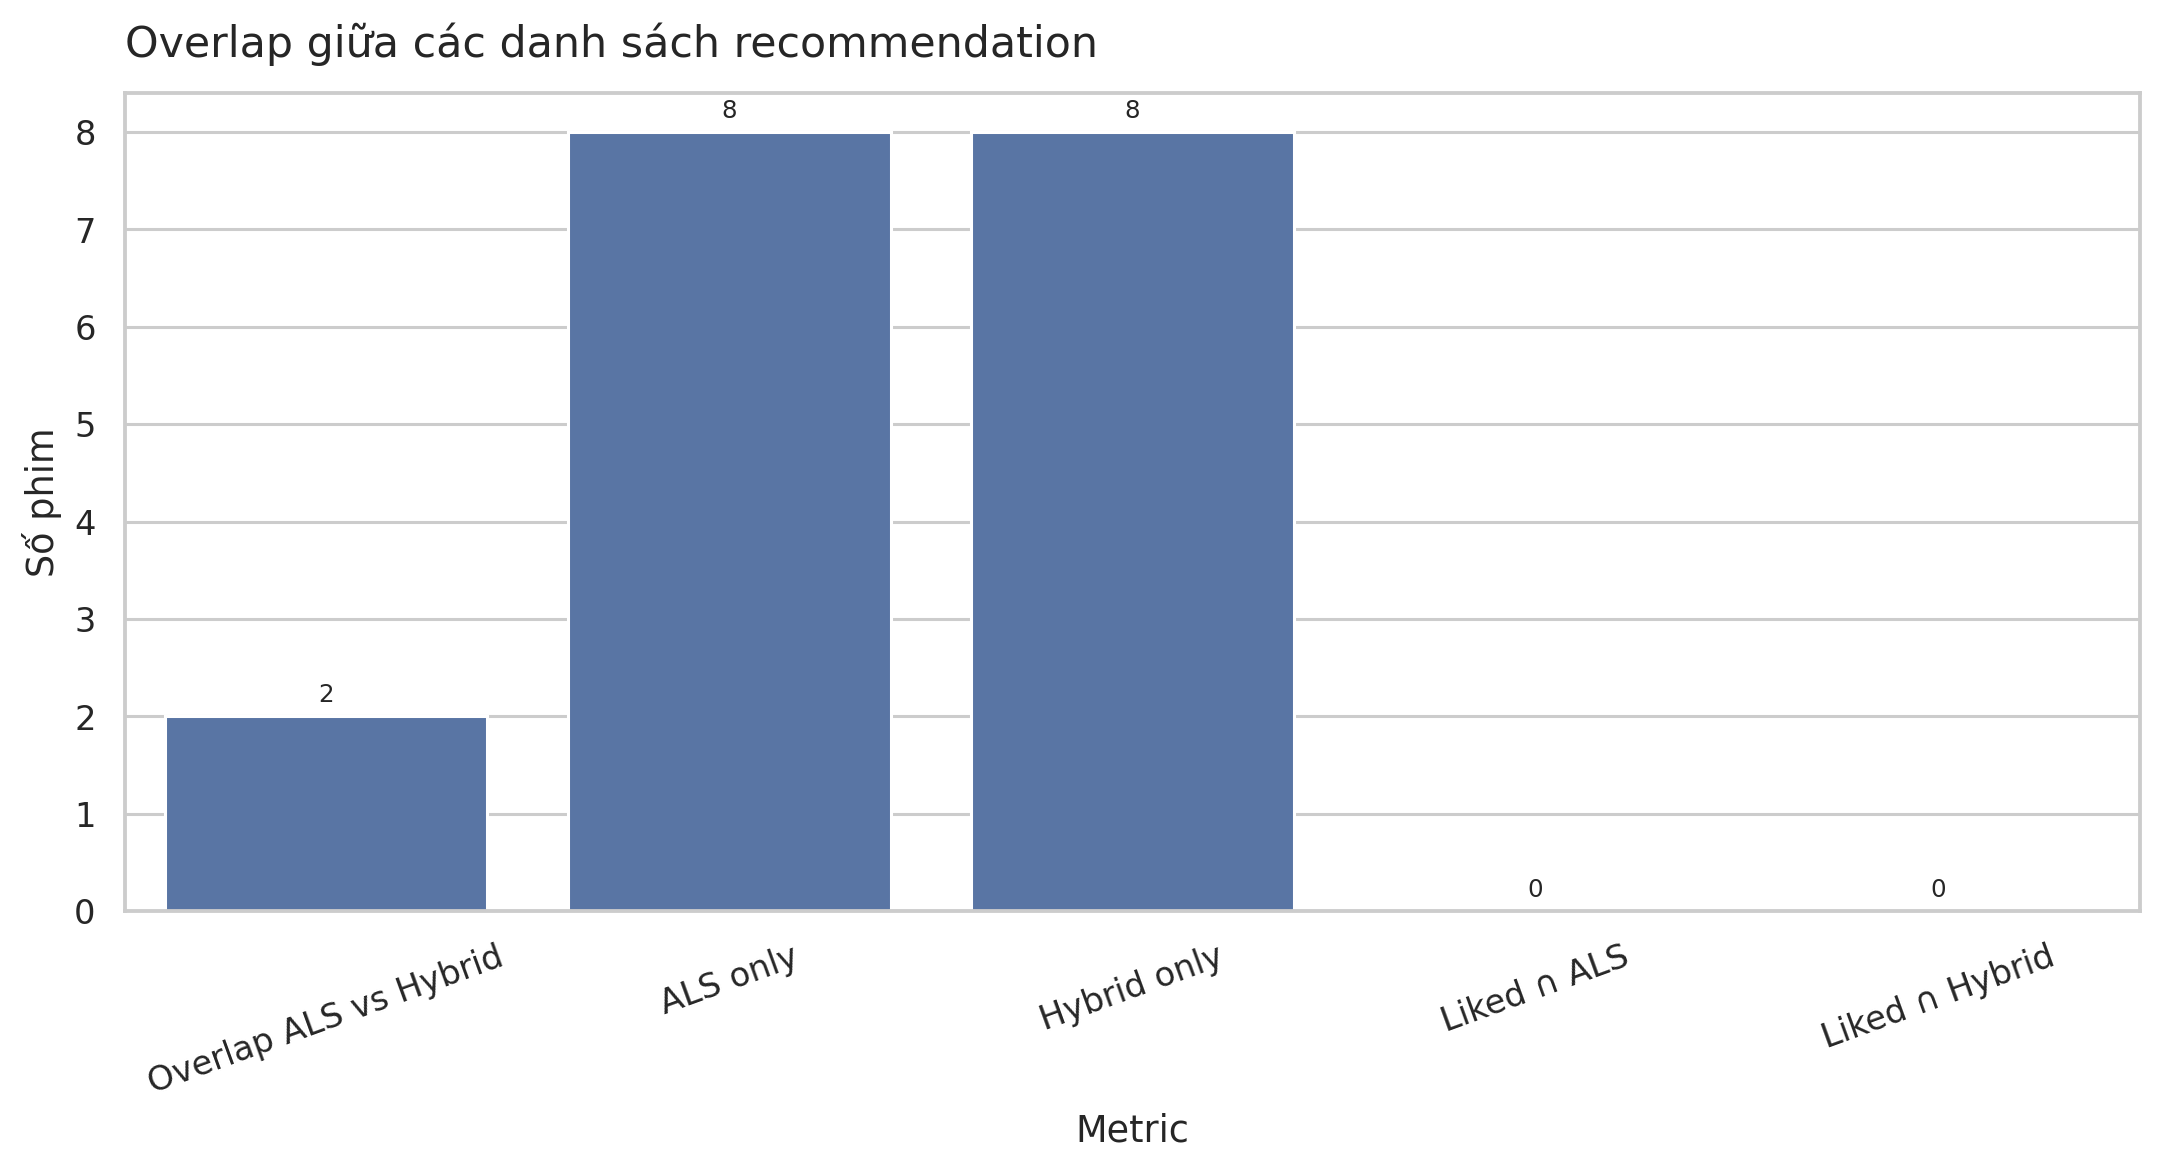

**final_report_storyboard_table**

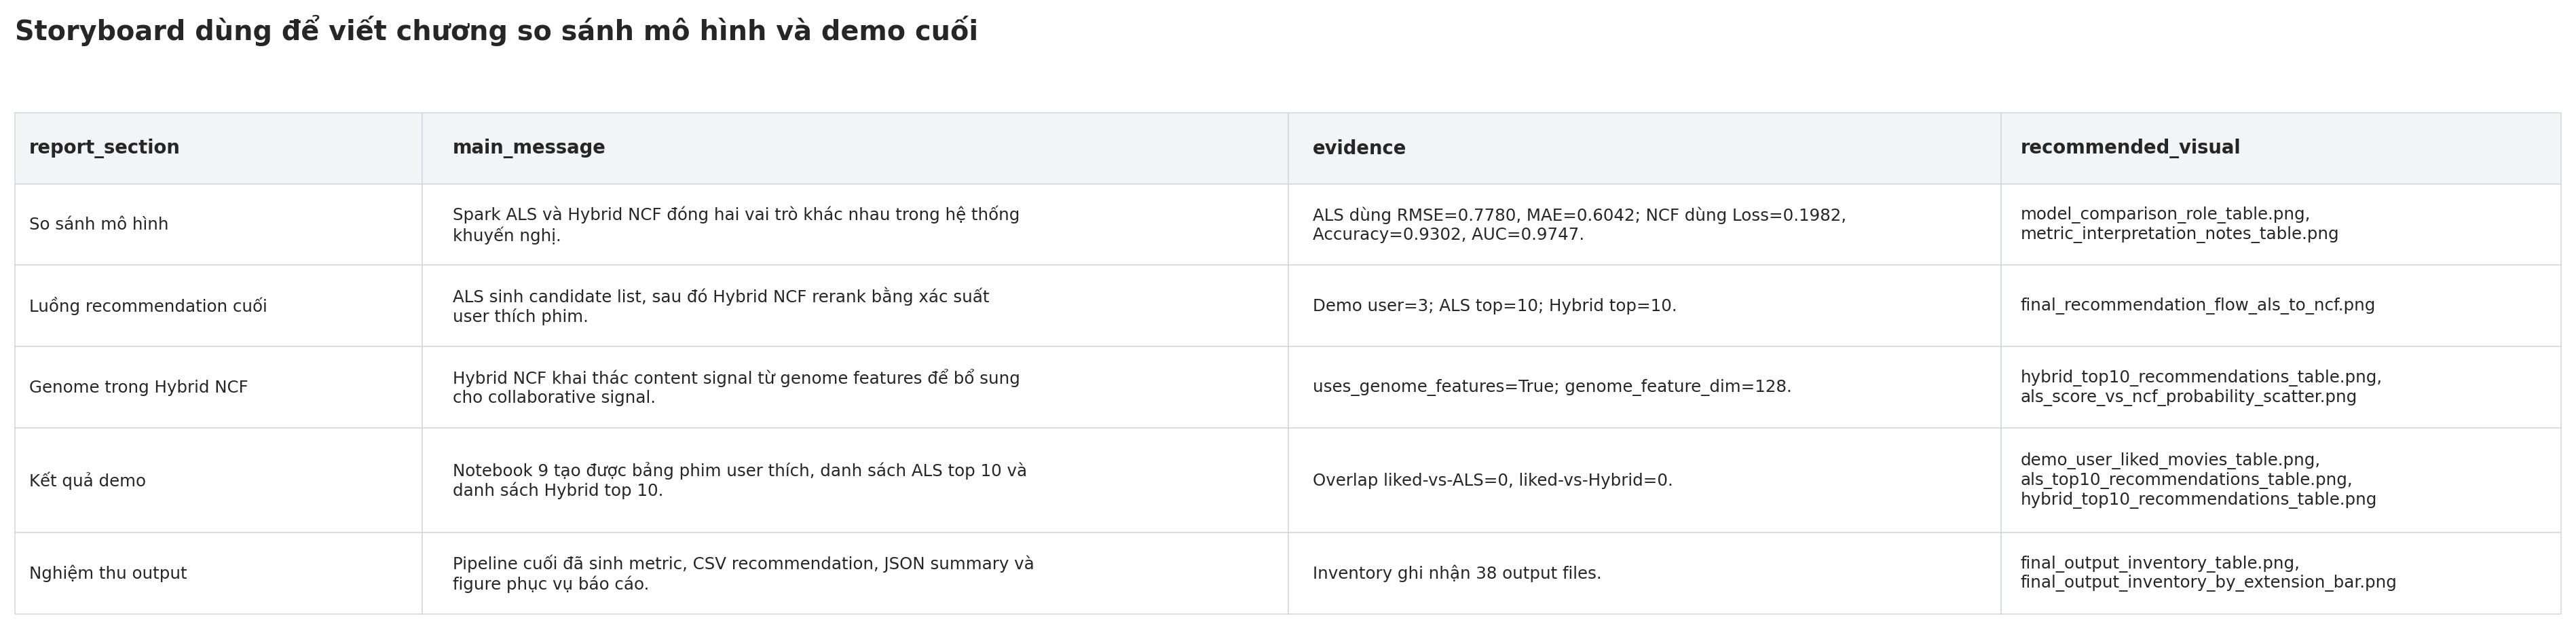

Done. Outputs written to: /workspace/outputs/reporting/reporting_layer_8_9_final_comparison_demo


In [12]:
manifest = {
    "report_slug": REPORT_SLUG,
    "created_at": RUN_TIMESTAMP,
    "source_groups": [
        "8_Compare_ALS_vs_NCF",
        "9_Final_Recommendation_Demo",
    ],
    "source_paths": {
        "metrics_dir": str(METRICS_DIR),
        "recommendations_dir": str(RECOMMENDATIONS_DIR),
        "source_figures_dir": str(SOURCE_FIGURES_DIR),
    },
    "report_dir": str(REPORT_DIR),
    "figures": figure_exports,
    "tables": table_exports,
    "metrics": metric_exports,
}

save_json(manifest, METRIC_DIR / "reporting_layer_8_9_manifest.json")

manifest_df = pd.DataFrame([
    {"asset_type": "figures", "count": len(figure_exports)},
    {"asset_type": "tables", "count": len(table_exports)},
    {"asset_type": "metrics_json", "count": len(metric_exports)},
    {"asset_type": "markdown", "count": len(list(MARKDOWN_DIR.glob('*.md')))},
])
save_table(manifest_df, "reporting_layer_8_9_manifest_summary")
display_df(manifest_df, "Reporting layer manifest summary", max_rows=10)

preview_figures([
    "model_comparison_role_table",
    "als_error_metrics_bar",
    "ncf_classification_metrics_bar",
    "final_dataset_summary_rows_logscale",
    "final_recommendation_flow_als_to_ncf",
    "recommendation_overlap_bar",
    "final_report_storyboard_table",
])

print("Done. Outputs written to:", REPORT_DIR)